# Overlap Group-Rep Retrieval Metrics

This notebook starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py`, uses the same matched-context reconstruction as `notebooks/overlap_group_rep_signature_similarity.ipynb`, and evaluates cross-dataset retrieval rather than direct matched-sample correlation.

For each dataset pair and matched `cell_type + pert_time_h` stratum, it constructs a retrieval task between all retained non-control compound-dose conditions in that stratum.

Eligibility rules:
- each side must have at least `2` unique compounds in the stratum
- the target-side candidate pool must contain at least `5` conditions
- a query is scored only if it has at least one positive in the target pool under the chosen retrieval variant

Representations:
- signed significance: `-log10(adj.P.Value) * sign(logFC)`
- moderated `t`
- `logFC`

Similarity:
- current retrieval uses negative Euclidean distance, i.e. similarity `S(i,j) = -||r_i - r_j||_2`
- it is not using cosine similarity

Primary retrieval variant:
- **compound across doses**: positives are all target-side conditions with the same compound, regardless of dose

Sensitivity variants:
- **dose-aware compound retrieval**: positives are same-compound candidates within `|Δ log10 dose| <= 1`, with nearest-dose fallback if none exist
- **strict matched-condition retrieval**: positives are only the reciprocal-nearest-dose matches reconstructed by the overlap matching logic

For each query, the notebook reports:
- normalized best-positive rank
- Recall@1
- AUROC over positives vs wrong-compound negatives

Retrieval is done in both directions (`A -> B` and `B -> A`). Summaries are aggregated by:
1. query
2. `dataset pair + direction + cell_type + time` stratum
3. dataset-pair direction
4. symmetric dataset pair, averaging the two directions


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import itertools

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [2]:
PRODUCTION_DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "tahoe",
    "cigs_mce",
    "novartis_batch_2500",
    "vcpi_0001",
    "cigs_tcm",
    "vcpi_0002",
    "gdpx2",
    "sciplex",
    "dilimap_train_val",
    "op3",
]
# Set this to a list such as ["tahoe", "sciplex"] for an isolated test run.
# Leave it as None for the production dataset set and production output directory.
TEST_DATASET_SUBSET = None
DATASET_ORDER = (
    list(PRODUCTION_DATASET_ORDER)
    if TEST_DATASET_SUBSET is None
    else list(dict.fromkeys(TEST_DATASET_SUBSET))
)
unknown_subset_datasets = sorted(set(DATASET_ORDER) - set(PRODUCTION_DATASET_ORDER))
if unknown_subset_datasets:
    raise ValueError(f"Unknown TEST_DATASET_SUBSET entries: {unknown_subset_datasets}")
if len(DATASET_ORDER) < 2:
    raise ValueError("Cross-dataset analysis requires at least two selected datasets.")
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "tahoe": "Tahoe-100M",
    "cigs_mce": "CIGS-MCE",
    "novartis_batch_2500": "Novartis/DRUG-seq U2OS",
    "vcpi_0001": "VCPI-0001",
    "cigs_tcm": "CIGS-TCM",
    "vcpi_0002": "VCPI-0002",
    "gdpx2": "GDPx2",
    "sciplex": "sci-Plex",
    "dilimap_train_val": "DILImap",
    "op3": "OP3",
}
config_start = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in [config_start, *config_start.parents]
     if (candidate / "results" / "overlap_filtered_h5ads").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")
DATA_ROOT = REPO_ROOT / "data" / "theislab_temp"
SOURCE_DATASET_DIRS = {
    "l1000_phase1": DATA_ROOT / "l1000_phase1" / "group_rep",
    "l1000_phase2": DATA_ROOT / "l1000_phase2" / "group_rep",
    "tahoe": DATA_ROOT / "tahoe" / "group_rep",
    "cigs_mce": DATA_ROOT / "cigs_mce" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "novartis_batch_2500": DATA_ROOT / "novartis_batch_2500" / "group_rep",
    "vcpi_0001": DATA_ROOT / "vcpi_0001" / "group_rep",
    "cigs_tcm": DATA_ROOT / "cigs_tcm" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "vcpi_0002": DATA_ROOT / "vcpi_0002" / "group_rep",
    "gdpx2": DATA_ROOT / "gdpx2" / "group_rep",
    "sciplex": DATA_ROOT / "sciplex" / "group_rep",
    "dilimap_train_val": DATA_ROOT / "dilimap_train_val" / "group_rep",
    "op3": DATA_ROOT / "op3" / "group_rep",
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
TOP_K = 50
NUMERIC_SIG_FIGS = 12
INVALID_STRING_VALUES = {"", "nan", "none", "<na>"}


def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
PRODUCTION_OUTPUT_DIR = REPO_ROOT / "results" / "overlap_group_rep_retrieval_metrics"
if TEST_DATASET_SUBSET is None:
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR
else:
    subset_run_label = "__".join(DATASET_ORDER)
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR.parent / "subset_runs" / PRODUCTION_OUTPUT_DIR.name / subset_run_label
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Datasets selected: {', '.join(DATASET_ORDER)}")
print(f"Output directory: {OUTPUT_DIR}")

Repository root: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis
Overlap directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads
Output directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics


In [3]:
def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def sanitize_string_values(series: pd.Series) -> pd.Series:
    normalized = series.astype("string").fillna("").astype(str).str.strip()
    normalized.loc[normalized.str.lower().isin(INVALID_STRING_VALUES)] = ""
    return normalized


def format_pubchem_cid(value: float) -> str:
    if float(value).is_integer():
        return str(int(value))
    return format_numeric(float(value))


def normalize_pubchem_cid_values(series: pd.Series) -> pd.Series:
    normalized = sanitize_string_values(series)
    numeric = pd.to_numeric(normalized, errors="coerce")
    finite_mask = np.isfinite(numeric.to_numpy(dtype=float))
    if not finite_mask.any():
        return normalized

    normalized = normalized.copy()
    normalized.loc[finite_mask] = numeric.loc[finite_mask].map(format_pubchem_cid)
    return normalized


def coerce_control_mask(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    normalized = values.astype("string").fillna("").astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes"})


EMPTY_OVERLAP_FRAME = pd.DataFrame(
    columns=[
        "dataset_name",
        "obs_id",
        "plate",
        "well",
        "pubchem_cid",
        "cell_type",
        "pert_time_h",
        "pert_dose_uM",
        "time_key",
        "dose_key",
        "log10_dose",
    ]
)


def load_overlap_obs(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()
    if "is_control" not in obs.columns:
        raise KeyError(f"{h5ad_path} is missing obs['is_control']")

    obs = obs.loc[~coerce_control_mask(obs["is_control"])].copy()
    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["obs_id"] = frame.index.astype(str)
    frame["plate"] = (
        obs["plate"].astype("string").fillna("").astype(str).str.strip()
        if "plate" in obs.columns
        else ""
    )
    frame["well"] = (
        obs["well"].astype("string").fillna("").astype(str).str.strip()
        if "well" in obs.columns
        else ""
    )
    context_column = "harmonized_context_key" if "harmonized_context_key" in obs.columns else "cell_type"
    frame["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(obs[context_column])
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def ensure_overlap_frame_schema(frame: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    if frame is None or frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = frame.copy()
    if "dataset_name" not in frame.columns:
        frame["dataset_name"] = dataset_name
    else:
        frame["dataset_name"] = frame["dataset_name"].astype("string").fillna(dataset_name).astype(str).str.strip()

    if "obs_id" not in frame.columns:
        frame["obs_id"] = pd.Index(frame.index).astype(str)
    else:
        frame["obs_id"] = frame["obs_id"].astype("string").fillna("").astype(str).str.strip()

    for column_name in ["plate", "well"]:
        if column_name not in frame.columns:
            frame[column_name] = ""
        else:
            frame[column_name] = frame[column_name].astype("string").fillna("").astype(str).str.strip()

    required_columns = ["pubchem_cid", "cell_type", "pert_time_h", "pert_dose_uM"]
    missing_columns = [column_name for column_name in required_columns if column_name not in frame.columns]
    if missing_columns:
        raise KeyError(
            f"Overlap frame for {dataset_name} is missing required columns: {missing_columns}"
        )

    frame["pubchem_cid"] = normalize_pubchem_cid_values(frame["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(frame["cell_type"])
    frame["pert_time_h"] = pd.to_numeric(frame["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(frame["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def build_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = ensure_overlap_frame_schema(load_overlap_obs(dataset_name), dataset_name)
    return {
        "frame": frame,
        "groups": build_groups(frame),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if dataset_name in dataset_indices and not dataset_indices[dataset_name]["frame"].empty
    ]


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


MATCH_PAIR_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "pubchem_cid",
    "time_key",
    "left_obs_id",
    "right_obs_id",
    "left_plate",
    "right_plate",
    "left_well",
    "right_well",
    "left_dose_key",
    "right_dose_key",
    "left_log10_dose",
    "right_log10_dose",
    "abs_delta_log10_dose",
    "matched_condition_key",
    "n_context_matching_drugs",
]


def pair_match_frame(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    *,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
    min_context_shared_drugs: int = MIN_CONTEXT_SHARED_DRUGS,
) -> pd.DataFrame:
    left_frame = ensure_overlap_frame_schema(left_index["frame"], left_dataset)
    right_frame = ensure_overlap_frame_schema(right_index["frame"], right_dataset)
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    if set(build_groups(left_frame)) != set(left_groups):
        left_groups = build_groups(left_frame)
    if set(build_groups(right_frame)) != set(right_groups):
        right_groups = build_groups(right_frame)

    if left_frame.empty or right_frame.empty:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    shared_keys = sorted(set(left_groups) & set(right_groups))
    if not shared_keys:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    left_obs_ids = left_frame["obs_id"].to_numpy(dtype=object)
    right_obs_ids = right_frame["obs_id"].to_numpy(dtype=object)
    left_plates = left_frame["plate"].to_numpy(dtype=object)
    right_plates = right_frame["plate"].to_numpy(dtype=object)
    left_wells = left_frame["well"].to_numpy(dtype=object)
    right_wells = right_frame["well"].to_numpy(dtype=object)
    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    context_matching_drugs: dict[tuple[str, str], set[str]] = defaultdict(set)
    rows: list[dict[str, object]] = []

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        for left_pos, right_pos in pairs:
            left_row = int(left_rows[left_pos])
            right_row = int(right_rows[right_pos])
            left_dose_key = str(left_dose_keys[left_row])
            right_dose_key = str(right_dose_keys[right_row])
            context_matching_drugs[(str(cell_type), str(time_key))].add(str(pubchem_cid))
            rows.append(
                {
                    "dataset_a": left_dataset,
                    "dataset_b": right_dataset,
                    "cell_type": str(cell_type),
                    "pubchem_cid": str(pubchem_cid),
                    "time_key": str(time_key),
                    "left_obs_id": str(left_obs_ids[left_row]),
                    "right_obs_id": str(right_obs_ids[right_row]),
                    "left_plate": str(left_plates[left_row]),
                    "right_plate": str(right_plates[right_row]),
                    "left_well": str(left_wells[left_row]),
                    "right_well": str(right_wells[right_row]),
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_log10_dose": float(left_log10_dose[left_row]),
                    "right_log10_dose": float(right_log10_dose[right_row]),
                    "abs_delta_log10_dose": float(abs(left_log10_dose[left_row] - right_log10_dose[right_row])),
                    "matched_condition_key": "|".join(
                        [
                            str(pubchem_cid),
                            str(cell_type),
                            str(time_key),
                            left_dose_key,
                            right_dose_key,
                        ]
                    ),
                }
            )

    if not rows:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame = pd.DataFrame(rows)
    qualifying_context_drug_counts = {
        context_key: len(compounds)
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= int(min_context_shared_drugs)
    }
    if not qualifying_context_drug_counts:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame["_context_key"] = list(zip(frame["cell_type"], frame["time_key"]))
    frame["n_context_matching_drugs"] = frame["_context_key"].map(qualifying_context_drug_counts)
    frame = frame.loc[frame["n_context_matching_drugs"].notna()].copy()
    frame["n_context_matching_drugs"] = frame["n_context_matching_drugs"].astype(int)
    frame = frame.drop(columns="_context_key")
    return frame[MATCH_PAIR_COLUMNS].reset_index(drop=True)



In [4]:
@dataclass
class LineSource:
    dataset_name: str
    cell_type: str
    path: Path
    adata: ad.AnnData = field(init=False, repr=False)
    obs: pd.DataFrame = field(init=False, repr=False)
    unique_gene_keys: np.ndarray = field(init=False, repr=False)
    unique_gene_positions: np.ndarray = field(init=False, repr=False)
    gene_to_pos: dict[str, int] = field(init=False, repr=False)
    lookup_row_pos: dict[str, int] = field(init=False, repr=False)
    _vector_cache: dict[tuple[str, int], np.ndarray] = field(default_factory=dict, init=False, repr=False)
    _baseline_cache: dict[tuple[str, int], object] = field(default_factory=dict, init=False, repr=False)
    _baseline_peer_counts: dict[int, int] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.adata = ad.read_h5ad(self.path, backed="r")
        obs = self.adata.obs.copy()
        row_positions = np.arange(self.adata.n_obs, dtype=np.int64)

        if "is_control" not in obs.columns:
            raise KeyError(f"{self.path} is missing obs['is_control']")

        obs["source_index"] = obs.index.astype(str)
        control_mask = coerce_control_mask(obs["is_control"]).to_numpy(dtype=bool)
        obs = obs.loc[~control_mask].copy()
        row_positions = row_positions[~control_mask]

        obs["source_row_pos"] = row_positions
        for column_name in [
            "id",
            "plate",
            "well",
            "cell_type",
            "perturbagen",
            "perturbagen_name",
            "perturbation_label",
            "pubchem_cid",
        ]:
            if column_name in obs.columns:
                obs[column_name] = obs[column_name].astype("string").fillna("").astype(str).str.strip()

        if "pubchem_cid" in obs.columns:
            obs["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])

        obs["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
        obs["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")
        obs["time_key"] = obs["pert_time_h"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) else ""
        )
        obs["dose_key"] = obs["pert_dose_uM"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) and float(value) > 0 else ""
        )

        valid_mask = (
            (obs["pubchem_cid"] != "")
            & np.isfinite(obs["pert_time_h"].to_numpy(dtype=float))
            & np.isfinite(obs["pert_dose_uM"].to_numpy(dtype=float))
            & (obs["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
        )
        obs = obs.loc[valid_mask].copy()
        obs = obs.set_index("source_row_pos", drop=False)
        self.obs = obs
        self.lookup_row_pos = self._build_lookup_row_pos()

        var = self.adata.var.copy()
        if "symbol" in var.columns:
            gene_key_series = pd.Series(
                var["symbol"].astype("string").fillna("").astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        else:
            gene_key_series = pd.Series(
                pd.Index(self.adata.var_names.astype(str)).astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        keep_mask = (gene_key_series != "") & ~gene_key_series.duplicated(keep="first")
        self.unique_gene_positions = gene_key_series.index[keep_mask].to_numpy(dtype=np.int64)
        self.unique_gene_keys = gene_key_series.loc[keep_mask].to_numpy(dtype=object)
        self.gene_to_pos = {
            str(gene_key): int(pos)
            for pos, gene_key in enumerate(self.unique_gene_keys.tolist())
        }

    def _build_lookup_row_pos(self) -> dict[str, int]:
        lookup_row_pos: dict[str, int] = {}

        def add_lookup_key(key: str, row_pos: int) -> None:
            if not key or key.lower() == "nan":
                return
            lookup_row_pos.setdefault(key, row_pos)

        for row_pos, row in self.obs.iterrows():
            row_pos = int(row_pos)
            for column_name in ["source_index", "id"]:
                if column_name in row.index:
                    add_lookup_key(str(row[column_name]).strip(), row_pos)

            cell_type = str(row.get("cell_type", "")).strip()
            pubchem_cid = str(row.get("pubchem_cid", "")).strip()
            dose_key = str(row.get("dose_key", "")).strip()
            time_key = str(row.get("time_key", "")).strip()

            if pubchem_cid and dose_key and time_key and cell_type:
                add_lookup_key(
                    f"{pubchem_cid}|{dose_key}|{time_key}|{cell_type}",
                    row_pos,
                )
        return lookup_row_pos

    def resolve_row_pos(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        obs_id = str(obs_id)
        candidate_keys = [obs_id]

        pubchem_cid = "" if pubchem_cid is None else str(pubchem_cid).strip()
        dose_key = "" if dose_key is None else str(dose_key).strip()
        time_key = "" if time_key is None else str(time_key).strip()

        if pubchem_cid and dose_key and time_key:
            candidate_keys.append(f"{pubchem_cid}|{dose_key}|{time_key}|{self.cell_type}")

        for candidate_key in candidate_keys:
            if candidate_key in self.lookup_row_pos:
                return int(self.lookup_row_pos[candidate_key])

        raise KeyError(
            f"Could not resolve obs_id={obs_id!r} in {self.path}. "
            f"Tried {candidate_keys!r}. Available lookup keys: {len(self.lookup_row_pos):,}"
        )

    def get_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> np.ndarray:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._vector_cache:
            vector = np.asarray(self.adata.layers[layer_name][row_pos], dtype=np.float32).reshape(-1)
            self._vector_cache[cache_key] = vector[self.unique_gene_positions]
        return self._vector_cache[cache_key]

    def get_baseline_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ):
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._baseline_cache:
            row = self.obs.loc[row_pos]
            peer_obs = self.obs.loc[
                (self.obs["dose_key"] == row["dose_key"])
                & (self.obs["time_key"] == row["time_key"])
                & (self.obs["pubchem_cid"] != row["pubchem_cid"])
            ]
            peer_rows = peer_obs["source_row_pos"].to_numpy(dtype=np.int64)
            self._baseline_peer_counts[row_pos] = int(len(peer_rows))
            if len(peer_rows) == 0:
                self._baseline_cache[cache_key] = None
            else:
                matrix = np.asarray(self.adata.layers[layer_name][peer_rows], dtype=np.float32)
                if matrix.ndim == 1:
                    matrix = matrix[np.newaxis, :]
                baseline = matrix[:, self.unique_gene_positions].mean(axis=0, dtype=np.float64)
                self._baseline_cache[cache_key] = np.asarray(baseline, dtype=np.float32)
        return self._baseline_cache[cache_key]

    def baseline_peer_count(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        if row_pos not in self._baseline_peer_counts:
            _ = self.get_baseline_vector(
                obs_id,
                "logFC",
                pubchem_cid=pubchem_cid,
                dose_key=dose_key,
                time_key=time_key,
                plate=plate,
                well=well,
            )
        return int(self._baseline_peer_counts.get(row_pos, 0))

    def close(self) -> None:
        self.adata.file.close()


def resolve_line_path(dataset_name: str, cell_type: str) -> Path:
    dataset_dir = SOURCE_DATASET_DIRS[dataset_name]
    candidates = [
        dataset_dir / f"{cell_type}_de.h5ad",
        dataset_dir / f"{cell_type}.h5ad",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find a line file for dataset={dataset_name}, cell_type={cell_type} in {dataset_dir}"
    )


LINE_SOURCE_CACHE: dict[tuple[str, str], LineSource] = {}
COMMON_GENE_CACHE: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def get_line_source(dataset_name: str, cell_type: str) -> LineSource:
    cache_key = (dataset_name, cell_type)
    if cache_key not in LINE_SOURCE_CACHE:
        LINE_SOURCE_CACHE[cache_key] = LineSource(
            dataset_name=dataset_name,
            cell_type=cell_type,
            path=resolve_line_path(dataset_name, cell_type),
        )
    return LINE_SOURCE_CACHE[cache_key]


def shared_gene_positions(
    left_source: LineSource,
    right_source: LineSource,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    cache_key = (left_source.dataset_name, right_source.dataset_name, left_source.cell_type)
    if cache_key not in COMMON_GENE_CACHE:
        shared_genes = [
            gene_key
            for gene_key in left_source.unique_gene_keys.tolist()
            if str(gene_key) in right_source.gene_to_pos
        ]
        left_positions = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        right_positions = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        COMMON_GENE_CACHE[cache_key] = (
            np.asarray(shared_genes, dtype=object),
            left_positions,
            right_positions,
        )
    return COMMON_GENE_CACHE[cache_key]

LINE_GLOBAL_SHARED_GENE_KEYS: dict[str, np.ndarray] = {}
GLOBAL_GENE_POSITION_CACHE: dict[tuple[str, str], np.ndarray] = {}


def set_global_shared_gene_keys(
    retained_lines: dict[str, list[str]],
    dataset_names: list[str],
) -> dict[str, np.ndarray]:
    global LINE_GLOBAL_SHARED_GENE_KEYS, GLOBAL_GENE_POSITION_CACHE

    cell_types = sorted(
        {
            cell_type
            for dataset_name in dataset_names
            for cell_type in retained_lines.get(dataset_name, [])
        }
    )
    line_gene_map: dict[str, np.ndarray] = {}
    for cell_type in cell_types:
        gene_sets: list[set[str]] = []
        for dataset_name in dataset_names:
            if cell_type not in retained_lines.get(dataset_name, []):
                continue
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            line_gene_map[cell_type] = np.empty(0, dtype=object)
        else:
            line_gene_map[cell_type] = np.asarray(sorted(set.intersection(*gene_sets)), dtype=object)

    LINE_GLOBAL_SHARED_GENE_KEYS = line_gene_map
    GLOBAL_GENE_POSITION_CACHE = {}
    return LINE_GLOBAL_SHARED_GENE_KEYS


def global_gene_positions(source: LineSource) -> tuple[np.ndarray, np.ndarray]:
    cache_key = (source.dataset_name, source.cell_type)
    line_gene_keys = LINE_GLOBAL_SHARED_GENE_KEYS.get(source.cell_type, np.empty(0, dtype=object))
    if line_gene_keys.size == 0:
        return line_gene_keys, np.empty(0, dtype=np.int64)
    if cache_key not in GLOBAL_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in line_gene_keys.tolist()
            if str(gene_key) not in source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"Line-specific shared-gene set is inconsistent for {(source.dataset_name, source.cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        GLOBAL_GENE_POSITION_CACHE[cache_key] = np.fromiter(
            (source.gene_to_pos[str(gene_key)] for gene_key in line_gene_keys.tolist()),
            dtype=np.int64,
            count=int(line_gene_keys.size),
        )
    return line_gene_keys, GLOBAL_GENE_POSITION_CACHE[cache_key]



def filter_finite_pair(left_values: np.ndarray, right_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    return left_values[mask], right_values[mask]


def signed_spearman(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    if left_values.size < 2:
        return float("nan")

    left_ranks = rankdata(left_values, method="average")
    right_ranks = rankdata(right_values, method="average")
    if np.allclose(left_ranks, left_ranks[0]) or np.allclose(right_ranks, right_ranks[0]):
        return float("nan")
    return float(np.corrcoef(left_ranks, right_ranks)[0, 1])


def signed_overlap_at_k(left_values: np.ndarray, right_values: np.ndarray, *, k: int = TOP_K) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    n_genes = int(left_values.size)
    k_eff = min(int(k), n_genes // 2)
    if k_eff < 1:
        return float("nan")

    top_left = np.argpartition(left_values, -k_eff)[-k_eff:]
    top_right = np.argpartition(right_values, -k_eff)[-k_eff:]
    bottom_left = np.argpartition(left_values, k_eff - 1)[:k_eff]
    bottom_right = np.argpartition(right_values, k_eff - 1)[:k_eff]

    top_overlap = np.intersect1d(top_left, top_right, assume_unique=False).size / k_eff
    bottom_overlap = np.intersect1d(bottom_left, bottom_right, assume_unique=False).size / k_eff
    return float(0.5 * (top_overlap + bottom_overlap))


def score_signature_pair(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
) -> dict[str, float]:
    return {
        "spearman_logfc": signed_spearman(left_logfc, right_logfc),
        "spearman_t": signed_spearman(left_t, right_t),
        f"signed_overlap_t_top{TOP_K}": signed_overlap_at_k(left_t, right_t, k=TOP_K),
    }


def mean_available(values: list[float]) -> float:
    finite_values = [value for value in values if pd.notna(value)]
    if not finite_values:
        return float("nan")
    return float(np.mean(finite_values))

def empty_score_dict() -> dict[str, float]:
    return {
        "spearman_logfc": float("nan"),
        "spearman_t": float("nan"),
        f"signed_overlap_t_top{TOP_K}": float("nan"),
    }



def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_t_full = left_source.get_vector(left_obs_id, "t", **left_lookup)
    right_t_full = right_source.get_vector(right_obs_id, "t", **right_lookup)

    observed_scores = score_signature_pair(
        left_logfc=left_logfc_full[left_gene_pos],
        right_logfc=right_logfc_full[right_gene_pos],
        left_t=left_t_full[left_gene_pos],
        right_t=right_t_full[right_gene_pos],
    )

    observed_scores_global = empty_score_dict()
    if global_shared_genes.size >= 2:
        observed_scores_global = score_signature_pair(
            left_logfc=left_logfc_full[left_global_gene_pos],
            right_logfc=right_logfc_full[right_global_gene_pos],
            left_t=left_t_full[left_global_gene_pos],
            right_t=right_t_full[right_global_gene_pos],
        )

    left_mean_abs_t = mean_available(np.abs(left_t_full[left_gene_pos]).tolist())
    right_mean_abs_t = mean_available(np.abs(right_t_full[right_gene_pos]).tolist())
    pair_mean_abs_t = mean_available([left_mean_abs_t, right_mean_abs_t])

    left_mean_abs_t_global = float("nan")
    right_mean_abs_t_global = float("nan")
    pair_mean_abs_t_global = float("nan")
    if global_shared_genes.size >= 2:
        left_mean_abs_t_global = mean_available(np.abs(left_t_full[left_global_gene_pos]).tolist())
        right_mean_abs_t_global = mean_available(np.abs(right_t_full[right_global_gene_pos]).tolist())
        pair_mean_abs_t_global = mean_available([left_mean_abs_t_global, right_mean_abs_t_global])

    left_baseline_logfc_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    left_baseline_t_full = left_source.get_baseline_vector(left_obs_id, "t", **left_lookup)
    right_baseline_logfc_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    right_baseline_t_full = right_source.get_baseline_vector(right_obs_id, "t", **right_lookup)

    left_baseline_scores = empty_score_dict()
    left_baseline_scores_global = empty_score_dict()
    if left_baseline_logfc_full is not None and left_baseline_t_full is not None:
        left_baseline_scores = score_signature_pair(
            left_logfc=left_logfc_full[left_gene_pos],
            right_logfc=left_baseline_logfc_full[left_gene_pos],
            left_t=left_t_full[left_gene_pos],
            right_t=left_baseline_t_full[left_gene_pos],
        )
        if global_shared_genes.size >= 2:
            left_baseline_scores_global = score_signature_pair(
                left_logfc=left_logfc_full[left_global_gene_pos],
                right_logfc=left_baseline_logfc_full[left_global_gene_pos],
                left_t=left_t_full[left_global_gene_pos],
                right_t=left_baseline_t_full[left_global_gene_pos],
            )

    right_baseline_scores = empty_score_dict()
    right_baseline_scores_global = empty_score_dict()
    if right_baseline_logfc_full is not None and right_baseline_t_full is not None:
        right_baseline_scores = score_signature_pair(
            left_logfc=right_logfc_full[right_gene_pos],
            right_logfc=right_baseline_logfc_full[right_gene_pos],
            left_t=right_t_full[right_gene_pos],
            right_t=right_baseline_t_full[right_gene_pos],
        )
        if global_shared_genes.size >= 2:
            right_baseline_scores_global = score_signature_pair(
                left_logfc=right_logfc_full[right_global_gene_pos],
                right_logfc=right_baseline_logfc_full[right_global_gene_pos],
                left_t=right_t_full[right_global_gene_pos],
                right_t=right_baseline_t_full[right_global_gene_pos],
            )

    overlap_column = f"signed_overlap_t_top{TOP_K}"
    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_global_common_genes": int(global_shared_genes.size),
        "left_mean_abs_t": left_mean_abs_t,
        "right_mean_abs_t": right_mean_abs_t,
        "pair_mean_abs_t": pair_mean_abs_t,
        "left_mean_abs_t_global": left_mean_abs_t_global,
        "right_mean_abs_t_global": right_mean_abs_t_global,
        "pair_mean_abs_t_global": pair_mean_abs_t_global,
        "observed_spearman_logfc": observed_scores["spearman_logfc"],
        "observed_spearman_logfc_global": observed_scores_global["spearman_logfc"],
        "observed_spearman_t": observed_scores["spearman_t"],
        "observed_spearman_t_global": observed_scores_global["spearman_t"],
        f"observed_{overlap_column}": observed_scores[overlap_column],
        f"observed_{overlap_column}_global": observed_scores_global[overlap_column],
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "left_baseline_spearman_logfc": left_baseline_scores["spearman_logfc"],
        "left_baseline_spearman_logfc_global": left_baseline_scores_global["spearman_logfc"],
        "left_baseline_spearman_t": left_baseline_scores["spearman_t"],
        "left_baseline_spearman_t_global": left_baseline_scores_global["spearman_t"],
        f"left_baseline_{overlap_column}": left_baseline_scores[overlap_column],
        f"left_baseline_{overlap_column}_global": left_baseline_scores_global[overlap_column],
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        "right_baseline_spearman_logfc": right_baseline_scores["spearman_logfc"],
        "right_baseline_spearman_logfc_global": right_baseline_scores_global["spearman_logfc"],
        "right_baseline_spearman_t": right_baseline_scores["spearman_t"],
        "right_baseline_spearman_t_global": right_baseline_scores_global["spearman_t"],
        f"right_baseline_{overlap_column}": right_baseline_scores[overlap_column],
        f"right_baseline_{overlap_column}_global": right_baseline_scores_global[overlap_column],
        "baseline_pair_mean_spearman_logfc": mean_available(
            [left_baseline_scores["spearman_logfc"], right_baseline_scores["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_logfc_global": mean_available(
            [left_baseline_scores_global["spearman_logfc"], right_baseline_scores_global["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_t": mean_available(
            [left_baseline_scores["spearman_t"], right_baseline_scores["spearman_t"]]
        ),
        "baseline_pair_mean_spearman_t_global": mean_available(
            [left_baseline_scores_global["spearman_t"], right_baseline_scores_global["spearman_t"]]
        ),
        f"baseline_pair_mean_{overlap_column}": mean_available(
            [left_baseline_scores[overlap_column], right_baseline_scores[overlap_column]]
        ),
        f"baseline_pair_mean_{overlap_column}_global": mean_available(
            [left_baseline_scores_global[overlap_column], right_baseline_scores_global[overlap_column]]
        ),
    }

def close_all_line_sources() -> None:
    for line_source in LINE_SOURCE_CACHE.values():
        line_source.close()



In [5]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No overlap-filtered non-control samples were found for the configured datasets.")

print("Datasets in scope:", ", ".join(pretty_label(dataset_name) for dataset_name in active_datasets))

retained_lines = {
    dataset_name: sorted(dataset_indices[dataset_name]["frame"]["cell_type"].unique().tolist())
    for dataset_name in active_datasets
}
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(dataset_name) for dataset_name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_keys = set_global_shared_gene_keys(retained_lines, active_datasets)
line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
print(f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} retained lines.")
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no retained line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        f"Line-specific shared-gene count range across retained lines: {min(line_global_gene_counts.values()):,} to {max(line_global_gene_counts.values()):,}"
    )

pair_match_frames: list[pd.DataFrame] = []
for dataset_a, dataset_b in itertools.combinations(active_datasets, 2):
    frame = pair_match_frame(
        left_dataset=dataset_a,
        right_dataset=dataset_b,
        left_index=dataset_indices[dataset_a],
        right_index=dataset_indices[dataset_b],
    )
    if not frame.empty:
        pair_match_frames.append(frame)

if not pair_match_frames:
    raise ValueError("No matched grouped-replicate sample pairs were found.")

matched_pairs = pd.concat(pair_match_frames, ignore_index=True)
matched_pairs_path = OUTPUT_DIR / "matched_sample_pairs.tsv"
matched_pairs.to_csv(matched_pairs_path, sep="\t", index=False)
print(f"Saved matched sample pairs to {matched_pairs_path}")

pair_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_lines=("cell_type", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
)
pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type"]) 
    .reset_index(drop=True)
)
line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)


Datasets in scope: L1000 Phase I, L1000 Phase II, Tahoe-100M, CIGS-MCE, CIGS-TCM, sci-Plex


,dataset,cell_types
0,L1000 Phase I,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
1,L1000 Phase II,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
2,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"
3,CIGS-MCE,"CVCL_0062, CVCL_0063"
4,CIGS-TCM,"CVCL_0062, CVCL_0063"
5,sci-Plex,"CVCL_0023, CVCL_0031"


/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.o

Line-specific shared-gene sets computed for 17 retained lines.
Line-specific shared-gene count range across retained lines: 599 to 978
Saved matched sample pairs to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/matched_sample_pairs.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,CIGS-MCE,CIGS-TCM,15973,974,2,1911
1,L1000 Phase I,CIGS-MCE,1401,124,2,127
2,L1000 Phase I,L1000 Phase II,50695,257,15,2836
3,L1000 Phase I,sci-Plex,2695,90,2,291
4,L1000 Phase I,Tahoe-100M,610,86,3,152
5,L1000 Phase II,CIGS-MCE,508,68,1,68
6,L1000 Phase II,sci-Plex,3192,83,2,381
7,L1000 Phase II,Tahoe-100M,1473,110,2,402
8,Tahoe-100M,sci-Plex,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,CIGS-MCE,CIGS-TCM,CVCL_0062,7842,948,948
1,CIGS-MCE,CIGS-TCM,CVCL_0063,8131,963,963
2,L1000 Phase I,CIGS-MCE,CVCL_0062,1047,113,113
3,L1000 Phase I,CIGS-MCE,CVCL_0063,354,14,14
4,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237
5,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615
6,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247
7,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190
8,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370
9,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114


**Retrieval Definitions**

For a fixed dataset pair and matched `cell_type + time_key` stratum, every retained condition in dataset A is queried against all retained conditions in dataset B within that same stratum.

The primary task is compound retrieval across doses. For query `i`, the positive set is all target-side conditions with the same `pubchem_cid`.

Scores:
- normalized best-positive rank: `1` is best, `0.5` is random on average, `0` is worst
- Recall@1
- AUROC with same-compound conditions as positives and other compounds as negatives

Candidates are scored by negative Euclidean distance on the chosen representation vector, so larger values mean smaller `L2` distance.

Additional baseline retrieval score:
- for each query, build a same-dataset baseline candidate by averaging all other compounds with the same `cell_type + time_key + dose_key`
- append that single baseline candidate to the cross-dataset target pool
- score the real query against `target pool ∪ {baseline candidate}`
- the baseline metrics report the rank of that injected baseline candidate within the augmented pool
- `observed - baseline` therefore compares the rank of the true cross-dataset match against the rank of the within-dataset baseline candidate


In [6]:
RETRIEVAL_VARIANTS = {
    "compound_across_doses": "Compound retrieval across doses",
    "dose_aware_compound": "Dose-aware compound retrieval",
    "strict_matched_condition": "Strict matched-condition retrieval",
}
REPRESENTATION_LABELS = {
    "signed_significance": "Signed significance",
    "moderated_t": "Moderated t",
    "logFC": "logFC",
}
MIN_TARGET_CANDIDATES = 5
MIN_UNIQUE_COMPOUNDS_PER_SIDE = 2
ADJ_PVALUE_LAYER_PREFERENCES = (
    "adj.P.Value.within_one_contrast",
    "adj.P.Value.across_all_contrasts",
)
ADJ_PVALUE_LAYER_CACHE: dict[tuple[str, str], str] = {}


def get_adjusted_pvalue_layer(source: LineSource) -> str:
    cache_key = (source.dataset_name, source.cell_type)
    if cache_key not in ADJ_PVALUE_LAYER_CACHE:
        available_layers = set(source.adata.layers.keys())
        for candidate in ADJ_PVALUE_LAYER_PREFERENCES:
            if candidate in available_layers:
                ADJ_PVALUE_LAYER_CACHE[cache_key] = candidate
                break
        else:
            raise KeyError(
                f"None of {ADJ_PVALUE_LAYER_PREFERENCES!r} are present in {source.path}; available layers: {sorted(available_layers)!r}"
            )
    return ADJ_PVALUE_LAYER_CACHE[cache_key]


def signed_significance(logfc: np.ndarray, adj_p: np.ndarray) -> np.ndarray:
    adj_p = np.asarray(adj_p, dtype=np.float64)
    logfc = np.asarray(logfc, dtype=np.float64)
    return -np.log10(np.clip(adj_p, 1e-300, None)) * np.sign(logfc)


def negative_l2_similarity_matrix(query_matrix: np.ndarray, candidate_matrix: np.ndarray) -> np.ndarray:
    query_matrix = np.asarray(query_matrix, dtype=np.float64)
    candidate_matrix = np.asarray(candidate_matrix, dtype=np.float64)
    diff = query_matrix[:, None, :] - candidate_matrix[None, :, :]
    with np.errstate(invalid="ignore"):
        distances = np.sqrt(np.sum(diff * diff, axis=2))
    return -distances


def normalized_best_positive_rank(scores: np.ndarray, positive_mask: np.ndarray) -> tuple[float, float]:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    if scores.size < 2 or int(positive_mask.sum()) == 0:
        return float("nan"), float("nan")
    ranks = rankdata(-scores, method="min")
    best_rank = float(np.min(ranks[positive_mask]))
    normalized_rank = 1.0 - ((best_rank - 1.0) / (len(scores) - 1.0))
    return float(best_rank), float(normalized_rank)


def recall_at_1(scores: np.ndarray, positive_mask: np.ndarray) -> float:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    if scores.size == 0 or int(positive_mask.sum()) == 0:
        return float("nan")
    ranks = rankdata(-scores, method="min")
    return float(np.min(ranks[positive_mask]) == 1)


def auroc_from_scores(scores: np.ndarray, positive_mask: np.ndarray) -> float:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    positive_scores = scores[positive_mask]
    negative_scores = scores[~positive_mask]
    if positive_scores.size == 0 or negative_scores.size == 0:
        return float("nan")
    wins = 0.0
    total = float(positive_scores.size * negative_scores.size)
    for positive_score in positive_scores:
        wins += float(np.sum(positive_score > negative_scores))
        wins += 0.5 * float(np.sum(np.isclose(positive_score, negative_scores, rtol=0.0, atol=1e-12)))
    return float(wins / total)


def summarize_retrieval_scores(scores: np.ndarray, positive_mask: np.ndarray) -> dict[str, float]:
    positive_mask = np.asarray(positive_mask, dtype=bool)
    scores = np.asarray(scores, dtype=np.float64)
    n_positives = int(np.sum(positive_mask))
    n_negatives = int(len(positive_mask) - n_positives)
    if n_positives == 0 or n_negatives == 0 or scores.size == 0 or not np.isfinite(scores).all():
        return {
            "n_positives": n_positives,
            "n_negatives": n_negatives,
            "best_rank": float("nan"),
            "normalized_rank": float("nan"),
            "recall_at_1": float("nan"),
            "auroc": float("nan"),
        }
    best_rank, normalized_rank = normalized_best_positive_rank(scores, positive_mask)
    return {
        "n_positives": n_positives,
        "n_negatives": n_negatives,
        "best_rank": best_rank,
        "normalized_rank": normalized_rank,
        "recall_at_1": recall_at_1(scores, positive_mask),
        "auroc": auroc_from_scores(scores, positive_mask),
    }


def difference_if_both_defined(observed: float, baseline: float) -> float:
    if pd.isna(observed) or pd.isna(baseline):
        return float("nan")
    return float(observed - baseline)


def build_strict_positive_maps(matched_pairs: pd.DataFrame) -> dict[tuple[str, str, str], dict[str, set[str]]]:
    maps: dict[tuple[str, str, str], dict[str, set[str]]] = {}
    for (dataset_a, dataset_b), group in matched_pairs.groupby(["dataset_a", "dataset_b"], sort=False):
        forward: dict[str, set[str]] = defaultdict(set)
        reverse: dict[str, set[str]] = defaultdict(set)
        for _, row in group.iterrows():
            forward[str(row["left_obs_id"])].add(str(row["right_obs_id"]))
            reverse[str(row["right_obs_id"])].add(str(row["left_obs_id"]))
        maps[(str(dataset_a), str(dataset_b), "A_to_B")] = forward
        maps[(str(dataset_a), str(dataset_b), "B_to_A")] = reverse
    return maps


def pool_frame_for_context(dataset_frame: pd.DataFrame, cell_type: str, time_key: str) -> pd.DataFrame:
    return dataset_frame.loc[
        (dataset_frame["cell_type"].astype(str) == str(cell_type))
        & (dataset_frame["time_key"].astype(str) == str(time_key))
    ].copy().reset_index(drop=True)


def build_pool_matrices(
    pool_frame: pd.DataFrame,
    source: LineSource,
    gene_positions: np.ndarray,
    *,
    adj_layer_name: str,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[dict[str, object]]]:
    resolved_rows: list[dict[str, object]] = []
    unresolved_records: list[dict[str, object]] = []
    logfc_rows: list[np.ndarray] = []
    t_rows: list[np.ndarray] = []
    adj_p_rows: list[np.ndarray] = []
    baseline_logfc_rows: list[np.ndarray] = []
    baseline_t_rows: list[np.ndarray] = []
    baseline_adj_p_rows: list[np.ndarray] = []
    baseline_peer_counts: list[int] = []
    n_genes = int(len(gene_positions))
    nan_vector = np.full(n_genes, np.nan, dtype=np.float64)

    for _, row in pool_frame.iterrows():
        lookup = {
            "pubchem_cid": str(row["pubchem_cid"]),
            "dose_key": str(row["dose_key"]),
            "time_key": str(row["time_key"]),
        }
        obs_id = str(row["obs_id"])
        try:
            logfc_rows.append(source.get_vector(obs_id, "logFC", **lookup)[gene_positions])
            t_rows.append(source.get_vector(obs_id, "t", **lookup)[gene_positions])
            adj_p_rows.append(source.get_vector(obs_id, adj_layer_name, **lookup)[gene_positions])

            baseline_logfc = source.get_baseline_vector(obs_id, "logFC", **lookup)
            baseline_t = source.get_baseline_vector(obs_id, "t", **lookup)
            baseline_adj_p = source.get_baseline_vector(obs_id, adj_layer_name, **lookup)
            baseline_peer_count = source.baseline_peer_count(obs_id, **lookup)
            baseline_peer_counts.append(int(baseline_peer_count))

            if baseline_logfc is None or baseline_t is None or baseline_adj_p is None:
                baseline_logfc_rows.append(nan_vector.copy())
                baseline_t_rows.append(nan_vector.copy())
                baseline_adj_p_rows.append(nan_vector.copy())
            else:
                baseline_logfc_rows.append(np.asarray(baseline_logfc, dtype=np.float64)[gene_positions])
                baseline_t_rows.append(np.asarray(baseline_t, dtype=np.float64)[gene_positions])
                baseline_adj_p_rows.append(np.asarray(baseline_adj_p, dtype=np.float64)[gene_positions])

            resolved_rows.append(row.to_dict())
        except KeyError as exc:
            unresolved_records.append({
                **row.to_dict(),
                "source_dataset": source.dataset_name,
                "source_cell_type": source.cell_type,
                "source_path": str(source.path),
                "adj_pvalue_layer": adj_layer_name,
                "error": str(exc),
            })
    if not logfc_rows:
        empty = np.empty((0, 0), dtype=np.float64)
        return (
            pool_frame.iloc[0:0].copy(),
            empty,
            empty,
            empty,
            empty,
            empty,
            empty,
            np.empty(0, dtype=np.int64),
            unresolved_records,
        )
    return (
        pd.DataFrame(resolved_rows).reset_index(drop=True),
        np.vstack(logfc_rows).astype(np.float64),
        np.vstack(t_rows).astype(np.float64),
        np.vstack(adj_p_rows).astype(np.float64),
        np.vstack(baseline_logfc_rows).astype(np.float64),
        np.vstack(baseline_t_rows).astype(np.float64),
        np.vstack(baseline_adj_p_rows).astype(np.float64),
        np.asarray(baseline_peer_counts, dtype=np.int64),
        unresolved_records,
    )


def primary_positive_mask(query_compound: str, candidate_compounds: np.ndarray) -> np.ndarray:
    return np.asarray(candidate_compounds, dtype=object) == str(query_compound)


def dose_aware_positive_mask(
    query_compound: str,
    query_log10_dose: float,
    candidate_compounds: np.ndarray,
    candidate_log10_doses: np.ndarray,
) -> np.ndarray:
    same_compound = np.asarray(candidate_compounds, dtype=object) == str(query_compound)
    if int(same_compound.sum()) == 0:
        return np.zeros(len(candidate_compounds), dtype=bool)
    dose_diff = np.abs(np.asarray(candidate_log10_doses, dtype=np.float64) - float(query_log10_dose))
    within = same_compound & (dose_diff <= MAX_LOG10_DOSE_DIFF + 1e-12)
    if int(within.sum()) > 0:
        return within
    nearest_diff = float(np.min(dose_diff[same_compound]))
    return same_compound & np.isclose(dose_diff, nearest_diff, rtol=0.0, atol=1e-12)


def strict_positive_mask(
    query_obs_id: str,
    candidate_obs_ids: np.ndarray,
    strict_map: dict[str, set[str]],
) -> np.ndarray:
    positives = strict_map.get(str(query_obs_id), set())
    if not positives:
        return np.zeros(len(candidate_obs_ids), dtype=bool)
    return np.asarray([str(obs_id) in positives for obs_id in candidate_obs_ids], dtype=bool)


def representation_matrices_from_raw(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
    left_adj_p: np.ndarray,
    right_adj_p: np.ndarray,
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    return {
        "signed_significance": (
            signed_significance(left_logfc, left_adj_p),
            signed_significance(right_logfc, right_adj_p),
        ),
        "moderated_t": (left_t, right_t),
        "logFC": (left_logfc, right_logfc),
    }


In [7]:
strict_positive_maps = build_strict_positive_maps(matched_pairs)
retrieval_records: list[dict[str, object]] = []
skipped_context_records: list[dict[str, object]] = []
unresolved_pool_records: list[dict[str, object]] = []

pair_contexts = (
    matched_pairs[["dataset_a", "dataset_b", "cell_type", "time_key"]]
    .drop_duplicates()
    .sort_values(["dataset_a", "dataset_b", "cell_type", "time_key"])
    .reset_index(drop=True)
)

for _, context_row in pair_contexts.iterrows():
    dataset_a = str(context_row["dataset_a"])
    dataset_b = str(context_row["dataset_b"])
    cell_type = str(context_row["cell_type"])
    time_key = str(context_row["time_key"])

    left_pool = pool_frame_for_context(dataset_indices[dataset_a]["frame"], cell_type, time_key)
    right_pool = pool_frame_for_context(dataset_indices[dataset_b]["frame"], cell_type, time_key)

    left_unique_compounds = int(left_pool["pubchem_cid"].astype(str).nunique())
    right_unique_compounds = int(right_pool["pubchem_cid"].astype(str).nunique())
    if (
        left_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
    ):
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "insufficient_candidates_or_unique_compounds",
                "n_left_conditions": int(len(left_pool)),
                "n_right_conditions": int(len(right_pool)),
                "n_left_unique_compounds": left_unique_compounds,
                "n_right_unique_compounds": right_unique_compounds,
            }
        )
        continue

    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_shared_genes",
                "n_shared_genes": int(shared_genes.size),
            }
        )
        continue

    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    (
        left_pool,
        left_logfc,
        left_t,
        left_adj_p,
        left_baseline_logfc,
        left_baseline_t,
        left_baseline_adj_p,
        left_baseline_peer_counts,
        left_unresolved,
    ) = build_pool_matrices(
        left_pool,
        left_source,
        left_gene_pos,
        adj_layer_name=left_adj_layer,
    )
    (
        right_pool,
        right_logfc,
        right_t,
        right_adj_p,
        right_baseline_logfc,
        right_baseline_t,
        right_baseline_adj_p,
        right_baseline_peer_counts,
        right_unresolved,
    ) = build_pool_matrices(
        right_pool,
        right_source,
        right_gene_pos,
        adj_layer_name=right_adj_layer,
    )
    unresolved_pool_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "cell_type": cell_type,
                "time_key": time_key,
                "pool_side": "left",
            }
            for record in left_unresolved
        ]
    )
    unresolved_pool_records.extend(
        [
            {
                **record,
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "cell_type": cell_type,
                "time_key": time_key,
                "pool_side": "right",
            }
            for record in right_unresolved
        ]
    )

    left_unique_compounds = int(left_pool["pubchem_cid"].astype(str).nunique())
    right_unique_compounds = int(right_pool["pubchem_cid"].astype(str).nunique())
    if (
        left_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or right_unique_compounds < MIN_UNIQUE_COMPOUNDS_PER_SIDE
        or len(left_pool) < MIN_TARGET_CANDIDATES
        or len(right_pool) < MIN_TARGET_CANDIDATES
    ):
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "insufficient_resolved_candidates_or_unique_compounds",
                "n_left_conditions": int(len(left_pool)),
                "n_right_conditions": int(len(right_pool)),
                "n_left_unique_compounds": left_unique_compounds,
                "n_right_unique_compounds": right_unique_compounds,
                "n_left_unresolved": int(len(left_unresolved)),
                "n_right_unresolved": int(len(right_unresolved)),
            }
        )
        continue

    finite_gene_mask = (
        np.isfinite(left_logfc).all(axis=0)
        & np.isfinite(right_logfc).all(axis=0)
        & np.isfinite(left_t).all(axis=0)
        & np.isfinite(right_t).all(axis=0)
        & np.isfinite(left_adj_p).all(axis=0)
        & np.isfinite(right_adj_p).all(axis=0)
    )
    shared_genes = shared_genes[finite_gene_mask]
    left_logfc = left_logfc[:, finite_gene_mask]
    right_logfc = right_logfc[:, finite_gene_mask]
    left_t = left_t[:, finite_gene_mask]
    right_t = right_t[:, finite_gene_mask]
    left_adj_p = left_adj_p[:, finite_gene_mask]
    right_adj_p = right_adj_p[:, finite_gene_mask]
    left_baseline_logfc = left_baseline_logfc[:, finite_gene_mask]
    right_baseline_logfc = right_baseline_logfc[:, finite_gene_mask]
    left_baseline_t = left_baseline_t[:, finite_gene_mask]
    right_baseline_t = right_baseline_t[:, finite_gene_mask]
    left_baseline_adj_p = left_baseline_adj_p[:, finite_gene_mask]
    right_baseline_adj_p = right_baseline_adj_p[:, finite_gene_mask]

    if shared_genes.size < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_finite_shared_genes",
                "n_shared_genes": int(shared_genes.size),
            }
        )
        continue

    representations = representation_matrices_from_raw(
        left_logfc,
        right_logfc,
        left_t,
        right_t,
        left_adj_p,
        right_adj_p,
    )
    baseline_representations = representation_matrices_from_raw(
        left_baseline_logfc,
        right_baseline_logfc,
        left_baseline_t,
        right_baseline_t,
        left_baseline_adj_p,
        right_baseline_adj_p,
    )

    directional_specs = [
        {
            "direction": "A_to_B",
            "query_dataset": dataset_a,
            "target_dataset": dataset_b,
            "query_pool": left_pool,
            "target_pool": right_pool,
            "query_side": 0,
            "target_side": 1,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "A_to_B"), {}),
            "query_baseline_peer_counts": left_baseline_peer_counts,
        },
        {
            "direction": "B_to_A",
            "query_dataset": dataset_b,
            "target_dataset": dataset_a,
            "query_pool": right_pool,
            "target_pool": left_pool,
            "query_side": 1,
            "target_side": 0,
            "strict_map": strict_positive_maps.get((dataset_a, dataset_b, "B_to_A"), {}),
            "query_baseline_peer_counts": right_baseline_peer_counts,
        },
    ]

    for direction_spec in directional_specs:
        query_pool = direction_spec["query_pool"].reset_index(drop=True)
        target_pool = direction_spec["target_pool"].reset_index(drop=True)
        if len(target_pool) < MIN_TARGET_CANDIDATES:
            continue

        query_compounds = query_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        target_compounds = target_pool["pubchem_cid"].astype(str).to_numpy(dtype=object)
        query_obs_ids = query_pool["obs_id"].astype(str).to_numpy(dtype=object)
        target_obs_ids = target_pool["obs_id"].astype(str).to_numpy(dtype=object)
        query_log10_doses = query_pool["log10_dose"].to_numpy(dtype=np.float64)
        target_log10_doses = target_pool["log10_dose"].to_numpy(dtype=np.float64)
        query_baseline_peer_counts = np.asarray(direction_spec["query_baseline_peer_counts"], dtype=np.int64)

        for representation_name, (left_matrix, right_matrix) in representations.items():
            baseline_left_matrix, baseline_right_matrix = baseline_representations[representation_name]
            if direction_spec["query_side"] == 0:
                query_matrix = left_matrix
                target_matrix = right_matrix
                query_baseline_matrix = baseline_left_matrix
            else:
                query_matrix = right_matrix
                target_matrix = left_matrix
                query_baseline_matrix = baseline_right_matrix

            similarity = negative_l2_similarity_matrix(query_matrix, target_matrix)
            for query_idx in range(len(query_pool)):
                query_compound = str(query_compounds[query_idx])
                query_obs_id = str(query_obs_ids[query_idx])
                query_log10_dose = float(query_log10_doses[query_idx])
                query_scores = similarity[query_idx]

                positive_masks = {
                    "compound_across_doses": primary_positive_mask(query_compound, target_compounds),
                    "dose_aware_compound": dose_aware_positive_mask(
                        query_compound,
                        query_log10_dose,
                        target_compounds,
                        target_log10_doses,
                    ),
                    "strict_matched_condition": strict_positive_mask(
                        query_obs_id,
                        target_obs_ids,
                        direction_spec["strict_map"],
                    ),
                }

                for retrieval_variant, positive_mask in positive_masks.items():
                    observed_metrics = summarize_retrieval_scores(query_scores, positive_mask)
                    if observed_metrics["n_positives"] == 0 or observed_metrics["n_negatives"] == 0:
                        continue

                    baseline_best_rank = float("nan")
                    baseline_normalized_rank = float("nan")
                    baseline_recall = float("nan")
                    baseline_auroc = float("nan")
                    baseline_candidate_similarity = float("nan")
                    baseline_available = False
                    if int(query_baseline_peer_counts[query_idx]) > 0:
                        baseline_candidate_vector = np.asarray(query_baseline_matrix[query_idx], dtype=np.float64)
                        query_vector = np.asarray(query_matrix[query_idx], dtype=np.float64)
                        if np.isfinite(baseline_candidate_vector).all() and np.isfinite(query_vector).all():
                            baseline_candidate_similarity = float(
                                negative_l2_similarity_matrix(
                                    query_vector[np.newaxis, :],
                                    baseline_candidate_vector[np.newaxis, :],
                                )[0, 0]
                            )
                            augmented_scores = np.concatenate(
                                [query_scores, np.asarray([baseline_candidate_similarity], dtype=np.float64)]
                            )
                            baseline_positive_mask = np.zeros(len(augmented_scores), dtype=bool)
                            baseline_positive_mask[-1] = True
                            baseline_metrics = summarize_retrieval_scores(
                                augmented_scores,
                                baseline_positive_mask,
                            )
                            baseline_best_rank = baseline_metrics["best_rank"]
                            baseline_normalized_rank = baseline_metrics["normalized_rank"]
                            baseline_recall = baseline_metrics["recall_at_1"]
                            baseline_auroc = baseline_metrics["auroc"]
                            baseline_available = np.isfinite(baseline_normalized_rank)

                    retrieval_records.append(
                        {
                            "dataset_a": dataset_a,
                            "dataset_b": dataset_b,
                            "direction": direction_spec["direction"],
                            "query_dataset": direction_spec["query_dataset"],
                            "target_dataset": direction_spec["target_dataset"],
                            "cell_type": cell_type,
                            "time_key": time_key,
                            "representation": representation_name,
                            "retrieval_variant": retrieval_variant,
                            "query_obs_id": query_obs_id,
                            "query_pubchem_cid": query_compound,
                            "query_dose_key": str(query_pool.loc[query_idx, "dose_key"]),
                            "query_log10_dose": query_log10_dose,
                            "target_pool_size": int(len(target_pool)),
                            "n_query_side_conditions": int(len(query_pool)),
                            "n_target_side_conditions": int(len(target_pool)),
                            "n_query_side_unique_compounds": int(query_pool["pubchem_cid"].astype(str).nunique()),
                            "n_target_side_unique_compounds": int(target_pool["pubchem_cid"].astype(str).nunique()),
                            "n_shared_genes": int(shared_genes.size),
                            "n_positive_candidates": observed_metrics["n_positives"],
                            "query_baseline_peer_count": int(query_baseline_peer_counts[query_idx]),
                            "baseline_candidate_similarity": baseline_candidate_similarity,
                            "baseline_available": bool(baseline_available),
                            "best_positive_rank": observed_metrics["best_rank"],
                            "normalized_best_positive_rank": observed_metrics["normalized_rank"],
                            "recall_at_1": observed_metrics["recall_at_1"],
                            "auroc": observed_metrics["auroc"],
                            "baseline_best_positive_rank": baseline_best_rank,
                            "baseline_normalized_best_positive_rank": baseline_normalized_rank,
                            "baseline_recall_at_1": baseline_recall,
                            "baseline_auroc": baseline_auroc,
                            "delta_vs_baseline_normalized_best_positive_rank": difference_if_both_defined(
                                observed_metrics["normalized_rank"],
                                baseline_normalized_rank,
                            ),
                            "delta_vs_baseline_recall_at_1": difference_if_both_defined(
                                observed_metrics["recall_at_1"],
                                baseline_recall,
                            ),
                            "delta_vs_baseline_auroc": difference_if_both_defined(
                                observed_metrics["auroc"],
                                baseline_auroc,
                            ),
                            "random_recall_at_1": float(observed_metrics["n_positives"] / len(target_pool)),
                            "random_normalized_best_positive_rank": 0.5,
                            "random_auroc": 0.5,
                        }
                    )

query_retrieval_metrics = pd.DataFrame(retrieval_records)
if query_retrieval_metrics.empty:
    raise ValueError("No eligible retrieval queries were scored.")

query_retrieval_metrics_path = OUTPUT_DIR / "query_retrieval_metrics.tsv"
query_retrieval_metrics.to_csv(query_retrieval_metrics_path, sep="	", index=False)
print(f"Saved query-level retrieval metrics to {query_retrieval_metrics_path}")
print(f"Scored {len(query_retrieval_metrics):,} retrieval queries")

skipped_contexts = pd.DataFrame(skipped_context_records)
if not skipped_contexts.empty:
    skipped_contexts_path = OUTPUT_DIR / "skipped_retrieval_contexts.tsv"
    skipped_contexts.to_csv(skipped_contexts_path, sep="	", index=False)
    print(f"Saved skipped retrieval contexts to {skipped_contexts_path}")

unresolved_pool_frame = pd.DataFrame(unresolved_pool_records)
if not unresolved_pool_frame.empty:
    unresolved_pool_path = OUTPUT_DIR / "unresolved_retrieval_pool_rows.tsv"
    unresolved_pool_frame.to_csv(unresolved_pool_path, sep="	", index=False)
    print(f"Saved unresolved retrieval pool rows to {unresolved_pool_path}")

stratum_retrieval_summary = (
    query_retrieval_metrics.groupby(
        ["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "cell_type", "time_key", "representation", "retrieval_variant"],
        as_index=False,
    )
    .agg(
        n_queries=("query_obs_id", "size"),
        n_queries_with_baseline=("baseline_normalized_best_positive_rank", lambda values: int(values.notna().sum())),
        n_unique_query_compounds=("query_pubchem_cid", "nunique"),
        mean_target_pool_size=("target_pool_size", "mean"),
        mean_shared_genes=("n_shared_genes", "mean"),
        mean_positive_candidates=("n_positive_candidates", "mean"),
        mean_query_baseline_peer_count=("query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("recall_at_1", "mean"),
        mean_baseline_recall_at_1=("baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("auroc", "mean"),
        mean_baseline_auroc=("baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "direction", "cell_type", "time_key", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
stratum_retrieval_summary_path = OUTPUT_DIR / "line_time_retrieval_summary.tsv"
stratum_retrieval_summary.to_csv(stratum_retrieval_summary_path, sep="	", index=False)
print(f"Saved line-time retrieval summary to {stratum_retrieval_summary_path}")

pair_direction_retrieval_summary = (
    stratum_retrieval_summary.groupby(
        ["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "representation", "retrieval_variant"],
        as_index=False,
    )
    .agg(
        n_line_time_strata=("cell_type", "size"),
        n_queries=("n_queries", "sum"),
        n_queries_with_baseline=("n_queries_with_baseline", "sum"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "direction", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
pair_direction_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_direction_retrieval_summary.tsv"
pair_direction_retrieval_summary.to_csv(pair_direction_retrieval_summary_path, sep="	", index=False)
print(f"Saved pair-direction retrieval summary to {pair_direction_retrieval_summary_path}")

pair_retrieval_summary = (
    pair_direction_retrieval_summary.groupby(["dataset_a", "dataset_b", "representation", "retrieval_variant"], as_index=False)
    .agg(
        n_directions=("direction", "size"),
        mean_line_time_strata=("n_line_time_strata", "mean"),
        mean_queries=("n_queries", "mean"),
        mean_queries_with_baseline=("n_queries_with_baseline", "mean"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
pair_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_retrieval_summary.tsv"
pair_retrieval_summary.to_csv(pair_retrieval_summary_path, sep="	", index=False)
print(f"Saved symmetric dataset-pair retrieval summary to {pair_retrieval_summary_path}")

line_retrieval_summary = (
    stratum_retrieval_summary.groupby(["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"], as_index=False)
    .agg(
        n_time_strata=("time_key", "size"),
        n_queries=("n_queries", "sum"),
        n_queries_with_baseline=("n_queries_with_baseline", "sum"),
        mean_query_baseline_peer_count=("mean_query_baseline_peer_count", "mean"),
        mean_normalized_best_positive_rank=("mean_normalized_best_positive_rank", "mean"),
        mean_baseline_normalized_best_positive_rank=("mean_baseline_normalized_best_positive_rank", "mean"),
        mean_delta_vs_baseline_normalized_best_positive_rank=("mean_delta_vs_baseline_normalized_best_positive_rank", "mean"),
        mean_recall_at_1=("mean_recall_at_1", "mean"),
        mean_baseline_recall_at_1=("mean_baseline_recall_at_1", "mean"),
        mean_delta_vs_baseline_recall_at_1=("mean_delta_vs_baseline_recall_at_1", "mean"),
        mean_auroc=("mean_auroc", "mean"),
        mean_baseline_auroc=("mean_baseline_auroc", "mean"),
        mean_delta_vs_baseline_auroc=("mean_delta_vs_baseline_auroc", "mean"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"])
    .reset_index(drop=True)
)
line_retrieval_summary_path = OUTPUT_DIR / "dataset_pair_line_retrieval_summary.tsv"
line_retrieval_summary.to_csv(line_retrieval_summary_path, sep="	", index=False)
print(f"Saved dataset-pair-line retrieval summary to {line_retrieval_summary_path}")

query_retrieval_metrics.head()


Saved query-level retrieval metrics to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/query_retrieval_metrics.tsv
Scored 387,696 retrieval queries
Saved unresolved retrieval pool rows to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/unresolved_retrieval_pool_rows.tsv
Saved line-time retrieval summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/line_time_retrieval_summary.tsv
Saved pair-direction retrieval summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/dataset_pair_direction_retrieval_summary.tsv
Saved symmetric dataset-pair retrieval summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/dataset_pair_retrieval_summary.tsv
Saved dataset-pair-line retrieval summary to

,dataset_a,dataset_b,direction,query_dataset,target_dataset,cell_type,time_key,representation,retrieval_variant,query_obs_id,...,baseline_best_positive_rank,baseline_normalized_best_positive_rank,baseline_recall_at_1,baseline_auroc,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_recall_at_1,delta_vs_baseline_auroc,random_recall_at_1,random_normalized_best_positive_rank,random_auroc
0,cigs_mce,cigs_tcm,A_to_B,cigs_mce,cigs_tcm,CVCL_0062,24,signed_significance,compound_across_doses,MCE4_231_24H_X1_B5_Myricetin_CVCL_0062,...,1.0,1.00000,1.0,1.00000,-0.011527,-1.0,-0.011536,0.00108,0.5,0.5
1,cigs_mce,cigs_tcm,A_to_B,cigs_mce,cigs_tcm,CVCL_0062,24,signed_significance,dose_aware_compound,MCE4_231_24H_X1_B5_Myricetin_CVCL_0062,...,1.0,1.00000,1.0,1.00000,-0.011527,-1.0,-0.011536,0.00108,0.5,0.5
2,cigs_mce,cigs_tcm,A_to_B,cigs_mce,cigs_tcm,CVCL_0062,24,signed_significance,strict_matched_condition,MCE4_231_24H_X1_B5_Myricetin_CVCL_0062,...,1.0,1.00000,1.0,1.00000,-0.011527,-1.0,-0.011536,0.00108,0.5,0.5
3,cigs_mce,cigs_tcm,A_to_B,cigs_mce,cigs_tcm,CVCL_0062,24,signed_significance,compound_across_doses,MCE4_231_24H_X1_P5_L-Glutamic_acid_CVCL_0062,...,1884.0,0.32193,0.0,0.32193,0.327926,0.0,0.327673,0.00108,0.5,0.5
4,cigs_mce,cigs_tcm,A_to_B,cigs_mce,cigs_tcm,CVCL_0062,24,signed_significance,dose_aware_compound,MCE4_231_24H_X1_P5_L-Glutamic_acid_CVCL_0062,...,1884.0,0.32193,0.0,0.32193,0.327926,0.0,0.327673,0.00108,0.5,0.5


In [8]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

retrieval_ci_source = query_retrieval_metrics.loc[
    (query_retrieval_metrics["retrieval_variant"] == "strict_matched_condition")
    & (query_retrieval_metrics["representation"] == "logFC")
].copy()
if retrieval_ci_source.empty:
    raise ValueError("No strict matched-condition logFC retrieval rows are available for cluster-BCa CIs.")

retrieval_ci_metrics = {
    "observed_normalized_best_positive_rank": "normalized_best_positive_rank",
    "baseline_normalized_best_positive_rank": "baseline_normalized_best_positive_rank",
    "delta_vs_baseline_normalized_best_positive_rank": "delta_vs_baseline_normalized_best_positive_rank",
}

overlap_retrieval_cluster_bca_ci = pd.concat(
    [
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["direction", "cell_type", "time_key"],
            outer_cols=["direction"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "direction", "query_dataset", "target_dataset", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["cell_type", "time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair_direction",
        ),
        cluster_bca_nested_mean_ci_table(
            retrieval_ci_source,
            group_cols=["dataset_a", "dataset_b", "cell_type", "representation", "retrieval_variant"],
            metric_cols=retrieval_ci_metrics,
            cluster_col="query_pubchem_cid",
            inner_cols=["time_key"],
            n_boot=BOOTSTRAP_ITERATIONS,
            seed=BOOTSTRAP_RANDOM_SEED,
            summary_level="dataset_pair_line",
        ),
    ],
    ignore_index=True,
)
overlap_retrieval_cluster_bca_ci_path = OUTPUT_DIR / "retrieval_strict_logfc_cluster_bca_ci.tsv"
overlap_retrieval_cluster_bca_ci.to_csv(overlap_retrieval_cluster_bca_ci_path, sep="\t", index=False)
print(f"Saved overlap retrieval cluster-BCa CI table to {overlap_retrieval_cluster_bca_ci_path}")

overlap_retrieval_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(overlap_retrieval_cluster_bca_ci)
overlap_retrieval_cluster_bca_ci_ranges_path = OUTPUT_DIR / "retrieval_strict_logfc_cluster_bca_ci_ranges.tsv"
overlap_retrieval_cluster_bca_ci_ranges.to_csv(overlap_retrieval_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved overlap retrieval CI half-width ranges to {overlap_retrieval_cluster_bca_ci_ranges_path}")
display(overlap_retrieval_cluster_bca_ci)
display(overlap_retrieval_cluster_bca_ci_ranges)


Saved overlap retrieval cluster-BCa CI table to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/retrieval_strict_logfc_cluster_bca_ci.tsv
Saved overlap retrieval CI half-width ranges to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/retrieval_strict_logfc_cluster_bca_ci_ranges.tsv


,dataset_a,dataset_b,representation,retrieval_variant,summary_level,metric,value_col,mean,ci_low,ci_high,...,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,direction,query_dataset,target_dataset,cell_type
0,cigs_mce,cigs_tcm,logFC,strict_matched_condition,dataset_pair,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.546882,0.536775,0.557450,...,11042,974,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
1,cigs_mce,cigs_tcm,logFC,strict_matched_condition,dataset_pair,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.998919,0.998138,0.999426,...,11042,974,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
2,cigs_mce,cigs_tcm,logFC,strict_matched_condition,dataset_pair,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_normalized_best_positive_rank,-0.452036,-0.462287,-0.441317,...,11042,974,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
3,l1000_phase1,cigs_mce,logFC,strict_matched_condition,dataset_pair,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.550590,0.490174,0.609182,...,855,124,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
4,l1000_phase1,cigs_mce,logFC,strict_matched_condition,dataset_pair,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.997481,0.993371,0.998940,...,855,124,query_pubchem_cid,"direction,cell_type,time_key",direction,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,l1000_phase2,tahoe,logFC,strict_matched_condition,dataset_pair_line,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.999656,0.999125,0.999872,...,1333,110,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0320
167,l1000_phase2,tahoe,logFC,strict_matched_condition,dataset_pair_line,delta_vs_baseline_normalized_best_positive_rank,delta_vs_baseline_normalized_best_positive_rank,-0.473733,-0.507884,-0.442631,...,1333,110,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0320
168,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_line,observed_normalized_best_positive_rank,normalized_best_positive_rank,0.569202,0.504719,0.636385,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023
169,tahoe,sciplex,logFC,strict_matched_condition,dataset_pair_line,baseline_normalized_best_positive_rank,baseline_normalized_best_positive_rank,0.999161,0.996700,1.000000,...,223,23,query_pubchem_cid,time_key,,95% BCa bootstrap CI clustered by PubChem comp...,NaN,NaN,NaN,CVCL_0023


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset_pair,baseline_normalized_best_positive_rank,9,0.000134,0.002784,0.011958,23,974,bca,ok
1,dataset_pair,delta_vs_baseline_normalized_best_positive_rank,9,0.010485,0.049124,0.067594,23,974,bca,ok
2,dataset_pair,observed_normalized_best_positive_rank,9,0.010337,0.045954,0.065178,23,974,bca,ok
3,dataset_pair_direction,baseline_normalized_best_positive_rank,18,0.000029,0.001511,0.025353,23,974,bca,ok
4,dataset_pair_direction,delta_vs_baseline_normalized_best_positive_rank,18,0.012970,0.058774,0.092436,23,974,bca,ok
5,dataset_pair_direction,observed_normalized_best_positive_rank,18,0.013354,0.057153,0.089933,23,974,bca,ok
6,dataset_pair_line,baseline_normalized_best_positive_rank,30,0.000000,0.008398,0.034937,11,962,"bca,degenerate","ok,zero_bootstrap_variance"
7,dataset_pair_line,delta_vs_baseline_normalized_best_positive_rank,30,0.013146,0.053694,0.163138,11,962,bca,ok
8,dataset_pair_line,observed_normalized_best_positive_rank,30,0.013001,0.054662,0.144186,11,962,bca,ok


**Primary Retrieval Task: Compound Retrieval Across Doses**

The main score is normalized best-positive rank. Random baseline is `0.5`.

This section now keeps both:
- direction-specific summaries (`A -> B` and `B -> A`) without averaging across directions
- symmetric dataset-pair summaries that average the two directions

It also reports the baseline rank of the injected same-line / same-time / same-dose other-compound mean candidate, plus the observed-minus-baseline delta.


In [9]:
primary_direction_summary = pair_direction_retrieval_summary.loc[
    pair_direction_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()
primary_pair_summary = pair_retrieval_summary.loc[
    pair_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()

primary_direction_summary["dataset_a"] = primary_direction_summary["dataset_a"].map(pretty_label)
primary_direction_summary["dataset_b"] = primary_direction_summary["dataset_b"].map(pretty_label)
primary_direction_summary["query_dataset"] = primary_direction_summary["query_dataset"].map(pretty_label)
primary_direction_summary["target_dataset"] = primary_direction_summary["target_dataset"].map(pretty_label)
primary_pair_summary["dataset_a"] = primary_pair_summary["dataset_a"].map(pretty_label)
primary_pair_summary["dataset_b"] = primary_pair_summary["dataset_b"].map(pretty_label)

for representation_name, representation_label in REPRESENTATION_LABELS.items():
    print(representation_label)

    direction_frame = primary_direction_summary.loc[
        primary_direction_summary["representation"] == representation_name
    ].copy()
    print("Direction-specific summary")
    display(direction_frame)
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_baseline_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_delta_vs_baseline_normalized_best_positive_rank"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_recall_at_1"))
    display(direction_frame.pivot(index="query_dataset", columns="target_dataset", values="mean_auroc"))

    representation_frame = primary_pair_summary.loc[
        primary_pair_summary["representation"] == representation_name
    ].copy()
    print("Symmetric pair summary")
    display(representation_frame)
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_vs_baseline_normalized_best_positive_rank"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_recall_at_1"))
    display(representation_frame.pivot(index="dataset_a", columns="dataset_b", values="mean_auroc"))


Signed significance
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
6,CIGS-MCE,CIGS-TCM,A_to_B,CIGS-MCE,CIGS-TCM,signed_significance,compound_across_doses,2,5463,5463,11468.918002,0.518654,0.582795,-0.064141,0.006106,0.182574,-0.176468,0.518325,0.582795,-0.064470
15,CIGS-MCE,CIGS-TCM,B_to_A,CIGS-TCM,CIGS-MCE,signed_significance,compound_across_doses,2,5579,5579,2125.564749,0.578734,0.746873,-0.168139,0.013981,0.014882,-0.000900,0.578464,0.746873,-0.168409
24,L1000 Phase I,CIGS-MCE,A_to_B,L1000 Phase I,CIGS-MCE,signed_significance,compound_across_doses,2,1176,1176,104.007583,0.476223,0.832299,-0.356076,0.053304,0.344350,-0.291046,0.475893,0.832299,-0.356406
33,L1000 Phase I,CIGS-MCE,B_to_A,CIGS-MCE,L1000 Phase I,signed_significance,compound_across_doses,2,349,349,11468.939064,0.599954,0.975776,-0.375821,0.046326,0.706129,-0.659804,0.517279,0.975776,-0.458496
42,L1000 Phase I,L1000 Phase II,A_to_B,L1000 Phase I,L1000 Phase II,signed_significance,compound_across_doses,17,11934,11902,1788.512049,0.790489,0.899319,-0.108513,0.227852,0.280009,-0.051773,0.641865,0.899319,-0.257466
51,L1000 Phase I,L1000 Phase II,B_to_A,L1000 Phase II,L1000 Phase I,signed_significance,compound_across_doses,17,10630,10613,494.245022,0.800380,0.888518,-0.087619,0.188574,0.141043,0.045067,0.668997,0.888518,-0.219311
60,L1000 Phase I,sci-Plex,A_to_B,L1000 Phase I,sci-Plex,signed_significance,compound_across_doses,2,1512,1512,3289.210860,0.769628,0.793125,-0.023497,0.076585,0.172191,-0.095606,0.596312,0.793125,-0.196813
69,L1000 Phase I,sci-Plex,B_to_A,sci-Plex,L1000 Phase I,signed_significance,compound_across_doses,2,765,765,181.922755,0.689882,0.976493,-0.286611,0.002237,0.184859,-0.182622,0.572134,0.976493,-0.404359
78,L1000 Phase I,Tahoe-100M,A_to_B,L1000 Phase I,Tahoe-100M,signed_significance,compound_across_doses,3,557,546,1525.700517,0.723948,0.882153,-0.150086,0.108911,0.289049,-0.180089,0.590429,0.882153,-0.286247
87,L1000 Phase I,Tahoe-100M,B_to_A,Tahoe-100M,L1000 Phase I,signed_significance,compound_across_doses,3,240,240,376.774329,0.600305,0.983823,-0.383518,0.030135,0.471451,-0.441316,0.528749,0.983823,-0.455075


target_dataset,CIGS-MCE,CIGS-TCM,L1000 Phase I,L1000 Phase II,Tahoe-100M,sci-Plex
query_dataset,,,,,,
CIGS-MCE,NaN,0.518654,0.599954,0.716484,NaN,NaN
CIGS-TCM,0.578734,NaN,NaN,NaN,NaN,NaN
L1000 Phase I,0.476223,NaN,NaN,0.790489,0.723948,0.769628
L1000 Phase II,0.511182,NaN,0.800380,NaN,0.767263,0.834667
Tahoe-100M,NaN,NaN,0.600305,0.736253,NaN,0.753362
sci-Plex,NaN,NaN,0.689882,0.784979,0.709888,NaN


target_dataset,CIGS-MCE,CIGS-TCM,L1000 Phase I,L1000 Phase II,Tahoe-100M,sci-Plex
query_dataset,,,,,,
CIGS-MCE,NaN,0.582795,0.975776,0.980162,NaN,NaN
CIGS-TCM,0.746873,NaN,NaN,NaN,NaN,NaN
L1000 Phase I,0.832299,NaN,NaN,0.899319,0.882153,0.793125
L1000 Phase II,0.779454,NaN,0.888518,NaN,0.870433,0.713910
Tahoe-100M,NaN,NaN,0.983823,0.974347,NaN,0.916906
sci-Plex,NaN,NaN,0.976493,0.972452,0.935836,NaN


target_dataset,CIGS-MCE,CIGS-TCM,L1000 Phase I,L1000 Phase II,Tahoe-100M,sci-Plex
query_dataset,,,,,,
CIGS-MCE,NaN,-0.064141,-0.375821,-0.263679,NaN,NaN
CIGS-TCM,-0.168139,NaN,NaN,NaN,NaN,NaN
L1000 Phase I,-0.356076,NaN,NaN,-0.108513,-0.150086,-0.023497
L1000 Phase II,-0.268272,NaN,-0.087619,NaN,-0.103169,0.120758
Tahoe-100M,NaN,NaN,-0.383518,-0.238095,NaN,-0.163543
sci-Plex,NaN,NaN,-0.286611,-0.187473,-0.225948,NaN


...

dataset_b,CIGS-MCE,CIGS-TCM,L1000 Phase II,Tahoe-100M,sci-Plex
dataset_a,,,,,
CIGS-MCE,NaN,0.546882,NaN,NaN,NaN
L1000 Phase I,0.553219,NaN,0.785894,0.616323,0.671672
L1000 Phase II,0.659170,NaN,NaN,0.688902,0.785075
Tahoe-100M,NaN,NaN,NaN,NaN,0.712734


dataset_b,CIGS-MCE,CIGS-TCM,L1000 Phase II,Tahoe-100M,sci-Plex
dataset_a,,,,,
CIGS-MCE,NaN,0.998919,NaN,NaN,NaN
L1000 Phase I,0.997478,NaN,0.968279,0.998459,0.990751
L1000 Phase II,0.995745,NaN,NaN,0.999881,0.999100
Tahoe-100M,NaN,NaN,NaN,NaN,0.999217


dataset_b,CIGS-MCE,CIGS-TCM,L1000 Phase II,Tahoe-100M,sci-Plex
dataset_a,,,,,
CIGS-MCE,NaN,-0.452036,NaN,NaN,NaN
L1000 Phase I,-0.444259,NaN,-0.183637,-0.385846,-0.319079
L1000 Phase II,-0.336575,NaN,NaN,-0.310980,-0.214025
Tahoe-100M,NaN,NaN,NaN,NaN,-0.286483


dataset_b,CIGS-MCE,CIGS-TCM,L1000 Phase II,Tahoe-100M,sci-Plex
dataset_a,,,,,
CIGS-MCE,NaN,0.014177,NaN,NaN,NaN
L1000 Phase I,0.067082,NaN,0.245518,0.066527,0.022826
L1000 Phase II,0.102881,NaN,NaN,0.042346,0.034581
Tahoe-100M,NaN,NaN,NaN,NaN,0.062489


dataset_b,CIGS-MCE,CIGS-TCM,L1000 Phase II,Tahoe-100M,sci-Plex
dataset_a,,,,,
CIGS-MCE,NaN,0.546593,NaN,NaN,NaN
L1000 Phase I,0.524987,NaN,0.674685,0.503943,0.556821
L1000 Phase II,0.583056,NaN,NaN,0.521776,0.604537
Tahoe-100M,NaN,NaN,NaN,NaN,0.549358


**Sensitivity Variants**

These tables summarize the stricter retrieval variants:
- dose-aware compound retrieval
- strict matched-condition retrieval

For each variant, the notebook keeps both direction-specific and symmetric pair summaries.


In [10]:
sensitivity_direction_summary = pair_direction_retrieval_summary.loc[
    pair_direction_retrieval_summary["retrieval_variant"] != "compound_across_doses"
].copy()
sensitivity_pair_summary = pair_retrieval_summary.loc[
    pair_retrieval_summary["retrieval_variant"] != "compound_across_doses"
].copy()

sensitivity_direction_summary["dataset_a"] = sensitivity_direction_summary["dataset_a"].map(pretty_label)
sensitivity_direction_summary["dataset_b"] = sensitivity_direction_summary["dataset_b"].map(pretty_label)
sensitivity_direction_summary["query_dataset"] = sensitivity_direction_summary["query_dataset"].map(pretty_label)
sensitivity_direction_summary["target_dataset"] = sensitivity_direction_summary["target_dataset"].map(pretty_label)
sensitivity_pair_summary["dataset_a"] = sensitivity_pair_summary["dataset_a"].map(pretty_label)
sensitivity_pair_summary["dataset_b"] = sensitivity_pair_summary["dataset_b"].map(pretty_label)

for retrieval_variant, retrieval_label in RETRIEVAL_VARIANTS.items():
    if retrieval_variant == "compound_across_doses":
        continue
    print(retrieval_label)
    variant_direction_frame = sensitivity_direction_summary.loc[
        sensitivity_direction_summary["retrieval_variant"] == retrieval_variant
    ].copy()
    variant_pair_frame = sensitivity_pair_summary.loc[
        sensitivity_pair_summary["retrieval_variant"] == retrieval_variant
    ].copy()
    for representation_name, representation_label in REPRESENTATION_LABELS.items():
        print(representation_label)
        direction_frame = variant_direction_frame.loc[
            variant_direction_frame["representation"] == representation_name
        ].copy()
        print("Direction-specific summary")
        display(direction_frame)
        pair_frame = variant_pair_frame.loc[
            variant_pair_frame["representation"] == representation_name
        ].copy()
        print("Symmetric pair summary")
        display(pair_frame)


Dose-aware compound retrieval
Signed significance
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
7,CIGS-MCE,CIGS-TCM,A_to_B,CIGS-MCE,CIGS-TCM,signed_significance,dose_aware_compound,2,5463,5463,11468.918002,0.518654,0.582795,-0.064141,0.006106,0.182574,-0.176468,0.518325,0.582795,-0.064470
16,CIGS-MCE,CIGS-TCM,B_to_A,CIGS-TCM,CIGS-MCE,signed_significance,dose_aware_compound,2,5579,5579,2125.564749,0.578734,0.746873,-0.168139,0.013981,0.014882,-0.000900,0.578464,0.746873,-0.168409
25,L1000 Phase I,CIGS-MCE,A_to_B,L1000 Phase I,CIGS-MCE,signed_significance,dose_aware_compound,2,1176,1176,104.007583,0.476223,0.832299,-0.356076,0.053304,0.344350,-0.291046,0.475893,0.832299,-0.356406
34,L1000 Phase I,CIGS-MCE,B_to_A,CIGS-MCE,L1000 Phase I,signed_significance,dose_aware_compound,2,349,349,11468.939064,0.537583,0.975776,-0.438192,0.041455,0.706129,-0.664674,0.490190,0.975776,-0.485585
43,L1000 Phase I,L1000 Phase II,A_to_B,L1000 Phase I,L1000 Phase II,signed_significance,dose_aware_compound,17,11934,11902,1788.512049,0.761054,0.899319,-0.137964,0.206771,0.280009,-0.072861,0.660085,0.899319,-0.239155
52,L1000 Phase I,L1000 Phase II,B_to_A,L1000 Phase II,L1000 Phase I,signed_significance,dose_aware_compound,17,10630,10613,494.245022,0.787174,0.888518,-0.100837,0.174274,0.141043,0.030759,0.692858,0.888518,-0.195433
61,L1000 Phase I,sci-Plex,A_to_B,L1000 Phase I,sci-Plex,signed_significance,dose_aware_compound,2,1512,1512,3289.210860,0.723050,0.793125,-0.070075,0.069841,0.172191,-0.102349,0.624770,0.793125,-0.168355
70,L1000 Phase I,sci-Plex,B_to_A,sci-Plex,L1000 Phase I,signed_significance,dose_aware_compound,2,765,765,181.922755,0.655423,0.976493,-0.321070,0.002237,0.184859,-0.182622,0.587764,0.976493,-0.388729
79,L1000 Phase I,Tahoe-100M,A_to_B,L1000 Phase I,Tahoe-100M,signed_significance,dose_aware_compound,3,557,546,1525.700517,0.646345,0.882153,-0.226967,0.067613,0.289049,-0.221387,0.603775,0.882153,-0.269923
88,L1000 Phase I,Tahoe-100M,B_to_A,Tahoe-100M,L1000 Phase I,signed_significance,dose_aware_compound,3,240,240,376.774329,0.559878,0.983823,-0.423946,0.023845,0.471451,-0.447605,0.524995,0.983823,-0.458829


Symmetric pair summary


,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
7,CIGS-MCE,CIGS-TCM,signed_significance,dose_aware_compound,2,2.0,5521.0,5521.0,6797.241376,0.548694,0.664834,-0.116140,0.010044,0.098728,-0.088684,0.548394,0.664834,-0.116440
16,L1000 Phase I,CIGS-MCE,signed_significance,dose_aware_compound,2,2.0,762.5,762.5,5786.473323,0.506903,0.904037,-0.397134,0.047380,0.525240,-0.477860,0.483042,0.904037,-0.420996
25,L1000 Phase I,L1000 Phase II,signed_significance,dose_aware_compound,2,17.0,11282.0,11257.5,1141.378536,0.774114,0.893918,-0.119401,0.190523,0.210526,-0.021051,0.676471,0.893918,-0.217294
34,L1000 Phase I,sci-Plex,signed_significance,dose_aware_compound,2,2.0,1138.5,1138.5,1735.566808,0.689237,0.884809,-0.195572,0.036039,0.178525,-0.142486,0.606267,0.884809,-0.278542
43,L1000 Phase I,Tahoe-100M,signed_significance,dose_aware_compound,2,3.0,398.5,393.0,951.237423,0.603111,0.932988,-0.325456,0.045729,0.380250,-0.334496,0.564385,0.932988,-0.364376
52,L1000 Phase II,CIGS-MCE,signed_significance,dose_aware_compound,2,1.0,465.5,465.5,5774.477046,0.500265,0.879808,-0.379543,0.043391,0.328130,-0.284739,0.457250,0.879808,-0.422558
61,L1000 Phase II,sci-Plex,signed_significance,dose_aware_compound,2,2.0,1397.5,1397.5,442.223848,0.759559,0.843181,-0.083622,0.051853,0.134609,-0.082756,0.648818,0.843181,-0.194362
70,L1000 Phase II,Tahoe-100M,signed_significance,dose_aware_compound,2,2.0,977.0,977.0,636.114852,0.669811,0.922390,-0.252579,0.024392,0.390436,-0.366044,0.584149,0.922390,-0.338241
79,Tahoe-100M,sci-Plex,signed_significance,dose_aware_compound,2,1.0,111.5,111.5,278.515686,0.629297,0.926371,-0.297074,0.073316,0.399233,-0.325916,0.555246,0.926371,-0.371125


Moderated t
Direction-specific summary


...

,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
5,CIGS-MCE,CIGS-TCM,moderated_t,strict_matched_condition,2,2.0,5521.0,5521.0,6797.241376,0.581793,0.999467,-0.417673,0.019651,0.962566,-0.942915,0.581514,0.999467,-0.417953
14,L1000 Phase I,CIGS-MCE,moderated_t,strict_matched_condition,2,2.0,427.5,427.5,5786.211090,0.555899,0.974092,-0.418192,0.064160,0.868669,-0.804508,0.547792,0.974092,-0.426299
23,L1000 Phase I,L1000 Phase II,moderated_t,strict_matched_condition,2,17.0,10928.5,10904.0,1141.640671,0.782027,0.948393,-0.167424,0.201980,0.607637,-0.404481,0.779237,0.948393,-0.170340
32,L1000 Phase I,sci-Plex,moderated_t,strict_matched_condition,2,2.0,948.5,948.5,1948.508676,0.672434,0.992342,-0.319908,0.034337,0.908839,-0.874502,0.671774,0.992342,-0.320568
41,L1000 Phase I,Tahoe-100M,moderated_t,strict_matched_condition,2,3.0,346.0,340.5,973.764667,0.597892,0.999856,-0.398130,0.031714,0.982652,-0.949152,0.593095,0.999856,-0.402935
50,L1000 Phase II,CIGS-MCE,moderated_t,strict_matched_condition,2,1.0,186.0,186.0,5773.372296,0.596461,0.903242,-0.306781,0.171053,0.846443,-0.675390,0.595871,0.903242,-0.307370
59,L1000 Phase II,sci-Plex,moderated_t,strict_matched_condition,2,2.0,1161.5,1161.5,465.865972,0.713637,0.991948,-0.278311,0.038920,0.921483,-0.882564,0.713097,0.991948,-0.278852
68,L1000 Phase II,Tahoe-100M,moderated_t,strict_matched_condition,2,2.0,877.5,877.5,637.938469,0.600839,0.999951,-0.399112,0.008890,0.988949,-0.980059,0.599220,0.999951,-0.400731
77,Tahoe-100M,sci-Plex,moderated_t,strict_matched_condition,2,1.0,111.5,111.5,278.515686,0.615709,0.999110,-0.383402,0.024893,0.976471,-0.951577,0.613162,0.999110,-0.385948


logFC
Direction-specific summary


,dataset_a,dataset_b,direction,query_dataset,target_dataset,representation,retrieval_variant,n_line_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
2,CIGS-MCE,CIGS-TCM,A_to_B,CIGS-MCE,CIGS-TCM,logFC,strict_matched_condition,2,5463,5463,11468.918002,0.551050,0.997917,-0.446868,0.017789,0.962778,-0.944989,0.550749,0.997917,-0.447169
11,CIGS-MCE,CIGS-TCM,B_to_A,CIGS-TCM,CIGS-MCE,logFC,strict_matched_condition,2,5579,5579,2125.564749,0.542715,0.999920,-0.457205,0.010565,0.979923,-0.969358,0.542437,0.999920,-0.457483
20,L1000 Phase I,CIGS-MCE,A_to_B,L1000 Phase I,CIGS-MCE,logFC,strict_matched_condition,2,506,506,103.483117,0.554728,0.999860,-0.445132,0.063164,0.865053,-0.801889,0.554459,0.999860,-0.445400
29,L1000 Phase I,CIGS-MCE,B_to_A,CIGS-MCE,L1000 Phase I,logFC,strict_matched_condition,2,349,349,11468.939064,0.546452,0.995102,-0.448650,0.069092,0.894441,-0.825348,0.532487,0.995102,-0.462615
38,L1000 Phase I,L1000 Phase II,A_to_B,L1000 Phase I,L1000 Phase II,logFC,strict_matched_condition,17,11896,11864,1791.986225,0.746764,0.977788,-0.231177,0.206428,0.735644,-0.528712,0.744269,0.977788,-0.233673
47,L1000 Phase I,L1000 Phase II,B_to_A,L1000 Phase II,L1000 Phase I,logFC,strict_matched_condition,17,9961,9944,491.295117,0.684729,0.958367,-0.276084,0.169455,0.684464,-0.516205,0.682116,0.958367,-0.278732
56,L1000 Phase I,sci-Plex,A_to_B,L1000 Phase I,sci-Plex,logFC,strict_matched_condition,2,1318,1318,3715.568983,0.623115,0.989374,-0.366259,0.022201,0.904884,-0.882683,0.622415,0.989374,-0.366959
65,L1000 Phase I,sci-Plex,B_to_A,sci-Plex,L1000 Phase I,logFC,strict_matched_condition,2,579,579,181.448369,0.558938,0.993037,-0.434099,0.010091,0.884580,-0.874489,0.558366,0.993037,-0.434671
74,L1000 Phase I,Tahoe-100M,A_to_B,L1000 Phase I,Tahoe-100M,logFC,strict_matched_condition,3,508,497,1570.345370,0.584523,0.996803,-0.419920,0.051187,0.929119,-0.894165,0.578345,0.996803,-0.426105
83,L1000 Phase I,Tahoe-100M,B_to_A,Tahoe-100M,L1000 Phase I,logFC,strict_matched_condition,3,184,184,377.183964,0.480305,0.999536,-0.519231,0.002849,0.988604,-0.985755,0.478612,0.999536,-0.520924


Symmetric pair summary


,dataset_a,dataset_b,representation,retrieval_variant,n_directions,mean_line_time_strata,mean_queries,mean_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
2,CIGS-MCE,CIGS-TCM,logFC,strict_matched_condition,2,2.0,5521.0,5521.0,6797.241376,0.546882,0.998919,-0.452036,0.014177,0.971350,-0.957173,0.546593,0.998919,-0.452326
11,L1000 Phase I,CIGS-MCE,logFC,strict_matched_condition,2,2.0,427.5,427.5,5786.211090,0.550590,0.997481,-0.446891,0.066128,0.879747,-0.813619,0.543473,0.997481,-0.454008
20,L1000 Phase I,L1000 Phase II,logFC,strict_matched_condition,2,17.0,10928.5,10904.0,1141.640671,0.715747,0.968078,-0.253630,0.187942,0.710054,-0.522459,0.713193,0.968078,-0.256203
29,L1000 Phase I,sci-Plex,logFC,strict_matched_condition,2,2.0,948.5,948.5,1948.508676,0.591026,0.991206,-0.400179,0.016146,0.894732,-0.878586,0.590390,0.991206,-0.400815
38,L1000 Phase I,Tahoe-100M,logFC,strict_matched_condition,2,3.0,346.0,340.5,973.764667,0.532414,0.998169,-0.469576,0.027018,0.958862,-0.939960,0.528478,0.998169,-0.473514
47,L1000 Phase II,CIGS-MCE,logFC,strict_matched_condition,2,1.0,186.0,186.0,5773.372296,0.579948,0.986389,-0.406441,0.065789,0.837739,-0.771949,0.579495,0.986389,-0.406894
56,L1000 Phase II,sci-Plex,logFC,strict_matched_condition,2,2.0,1161.5,1161.5,465.865972,0.653162,0.998990,-0.345828,0.018584,0.941650,-0.923066,0.652625,0.998990,-0.346365
65,L1000 Phase II,Tahoe-100M,logFC,strict_matched_condition,2,2.0,877.5,877.5,637.938469,0.522789,0.999875,-0.477087,0.003684,0.988465,-0.984781,0.521865,0.999875,-0.478010
74,Tahoe-100M,sci-Plex,logFC,strict_matched_condition,2,1.0,111.5,111.5,278.515686,0.562807,0.999217,-0.436410,0.034868,0.959250,-0.924382,0.560593,0.999217,-0.438625


**Line-Level Primary Retrieval Summary**

These line-level summaries average across matched `time_key` strata and both directions for the primary across-dose compound retrieval task.


In [11]:
primary_line_summary = line_retrieval_summary.loc[
    line_retrieval_summary["retrieval_variant"] == "compound_across_doses"
].copy()
primary_line_summary["dataset_a"] = primary_line_summary["dataset_a"].map(pretty_label)
primary_line_summary["dataset_b"] = primary_line_summary["dataset_b"].map(pretty_label)
display(primary_line_summary)


,dataset_a,dataset_b,cell_type,representation,retrieval_variant,n_time_strata,n_queries,n_queries_with_baseline,mean_query_baseline_peer_count,mean_normalized_best_positive_rank,mean_baseline_normalized_best_positive_rank,mean_delta_vs_baseline_normalized_best_positive_rank,mean_recall_at_1,mean_baseline_recall_at_1,mean_delta_vs_baseline_recall_at_1,mean_auroc,mean_baseline_auroc,mean_delta_vs_baseline_auroc
0,CIGS-MCE,CIGS-TCM,CVCL_0062,logFC,compound_across_doses,2,5453,5453,6771.229832,0.560448,0.997984,-0.437537,0.013857,0.965073,-0.951216,0.560176,0.997984,-0.437809
3,CIGS-MCE,CIGS-TCM,CVCL_0062,moderated_t,compound_across_doses,2,5453,5453,6771.229832,0.598057,0.999244,-0.401188,0.020882,0.956778,-0.935895,0.597792,0.999244,-0.401452
6,CIGS-MCE,CIGS-TCM,CVCL_0062,signed_significance,compound_across_doses,2,5453,5453,6771.229832,0.558151,0.722719,-0.164568,0.011693,0.132549,-0.120855,0.557862,0.722719,-0.164857
9,CIGS-MCE,CIGS-TCM,CVCL_0063,logFC,compound_across_doses,2,5589,5589,6823.252919,0.533316,0.999853,-0.466536,0.014497,0.977627,-0.963130,0.533010,0.999853,-0.466843
12,CIGS-MCE,CIGS-TCM,CVCL_0063,moderated_t,compound_across_doses,2,5589,5589,6823.252919,0.565530,0.999689,-0.434159,0.018419,0.968355,-0.949936,0.565235,0.999689,-0.434454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,L1000 Phase II,Tahoe-100M,CVCL_0320,moderated_t,compound_across_doses,2,1386,1386,920.135157,0.725310,0.999898,-0.274588,0.026939,0.981452,-0.954512,0.568898,0.999898,-0.430999
258,L1000 Phase II,Tahoe-100M,CVCL_0320,signed_significance,compound_across_doses,2,1386,1386,920.135157,0.718696,0.929764,-0.211068,0.018335,0.330989,-0.312654,0.556859,0.929764,-0.372905
261,Tahoe-100M,sci-Plex,CVCL_0023,logFC,compound_across_doses,2,223,223,278.515686,0.712734,0.999217,-0.286483,0.062489,0.959250,-0.896760,0.549358,0.999217,-0.449860
264,Tahoe-100M,sci-Plex,CVCL_0023,moderated_t,compound_across_doses,2,223,223,278.515686,0.775719,0.999110,-0.223391,0.055669,0.976471,-0.920801,0.591754,0.999110,-0.407356


Optional cleanup:

```python
close_all_line_sources()
```


**Strict Matched-Condition Retrieval Heatmaps**

These heatmaps summarize the symmetric dataset-pair retrieval results for the `logFC` representation under the strict matched-condition retrieval variant.

They show:
- observed normalized best-positive rank
- baseline normalized best-positive rank
- observed minus baseline normalized best-positive rank

As in [overlap_group_rep_deg_metrics.ipynb](./overlap_group_rep_deg_metrics.ipynb), the layout is lower-triangular and the diagonal is masked because these are cross-dataset summaries only.

In [12]:
RETRIEVAL_HEATMAP_OUTPUT_PATHS = {
    "observed": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_observed_normalized_rank_heatmap.pdf",
    "baseline": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_baseline_normalized_rank_heatmap.pdf",
    "delta": OUTPUT_DIR / "dataset_pair_strict_matched_condition_logfc_delta_normalized_rank_heatmap.pdf",
}


def build_symmetric_pair_metric_matrix(
    summary_frame: pd.DataFrame,
    value_col: str,
    dataset_order: list[str],
) -> pd.DataFrame:
    matrix = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order, dtype=float)
    for _, row in summary_frame.iterrows():
        dataset_a = str(row["dataset_a"])
        dataset_b = str(row["dataset_b"])
        if dataset_a not in matrix.index or dataset_b not in matrix.columns:
            continue
        value = pd.to_numeric(pd.Series([row[value_col]]), errors="coerce").iloc[0]
        matrix.loc[dataset_a, dataset_b] = value
        matrix.loc[dataset_b, dataset_a] = value
    return matrix


def plot_pair_metric_heatmap(
    summary_frame: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    dataset_order: list[str],
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center: Optional[float] = None,
    cbar_label: Optional[str] = None,
):
    matrix = build_symmetric_pair_metric_matrix(summary_frame, value_col, dataset_order)
    display_matrix = matrix.rename(index=pretty_label, columns=pretty_label).iloc[1:, :-1]
    mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)

    fig_width = max(5.5, 1.35 * len(display_matrix.columns))
    fig_height = max(4.5, 1.15 * len(display_matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    sns.heatmap(
        display_matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {output_path}")


heatmap_dataset_order = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in active_datasets]
strict_logfc_pair_summary = pair_retrieval_summary.loc[
    (pair_retrieval_summary["retrieval_variant"] == "strict_matched_condition")
    & (pair_retrieval_summary["representation"] == "logFC")
].copy()

if strict_logfc_pair_summary.empty:
    raise ValueError("No symmetric strict matched-condition logFC retrieval rows are available for heatmap plotting.")

observed_baseline_values = pd.concat(
    [
        strict_logfc_pair_summary["mean_normalized_best_positive_rank"],
        strict_logfc_pair_summary["mean_baseline_normalized_best_positive_rank"],
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
if observed_baseline_values.empty:
    observed_baseline_vmin = None
    observed_baseline_vmax = None
else:
    observed_baseline_vmin = float(observed_baseline_values.min())
    observed_baseline_vmax = float(observed_baseline_values.max())

delta_values = strict_logfc_pair_summary["mean_delta_vs_baseline_normalized_best_positive_rank"].replace([np.inf, -np.inf], np.nan).dropna()
delta_abs_max = None if delta_values.empty else float(np.nanmax(np.abs(delta_values.to_numpy(dtype=float))))

print("Heatmap datasets:", ", ".join(pretty_label(dataset_name) for dataset_name in heatmap_dataset_order))


Heatmap datasets: L1000 Phase I, L1000 Phase II, Tahoe-100M, CIGS-MCE, CIGS-TCM, sci-Plex


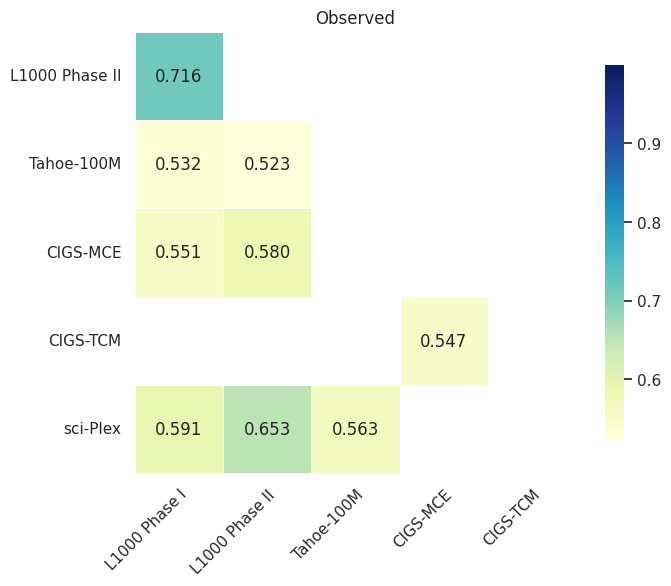

Saved heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/dataset_pair_strict_matched_condition_logfc_observed_normalized_rank_heatmap.pdf


In [13]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_normalized_best_positive_rank",
    title="Observed",
    cmap="YlGnBu",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["observed"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Observed normalized rank",
)


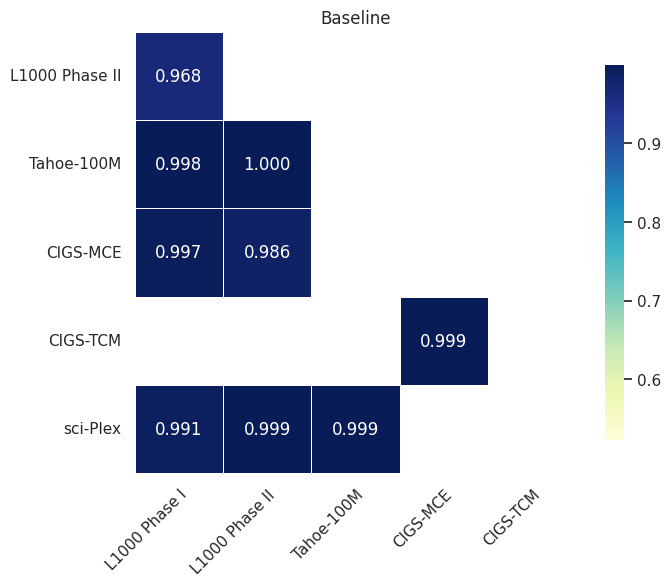

Saved heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/dataset_pair_strict_matched_condition_logfc_baseline_normalized_rank_heatmap.pdf


In [14]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_baseline_normalized_best_positive_rank",
    title="Baseline",
    cmap="YlGnBu",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["baseline"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Baseline normalized rank",
)


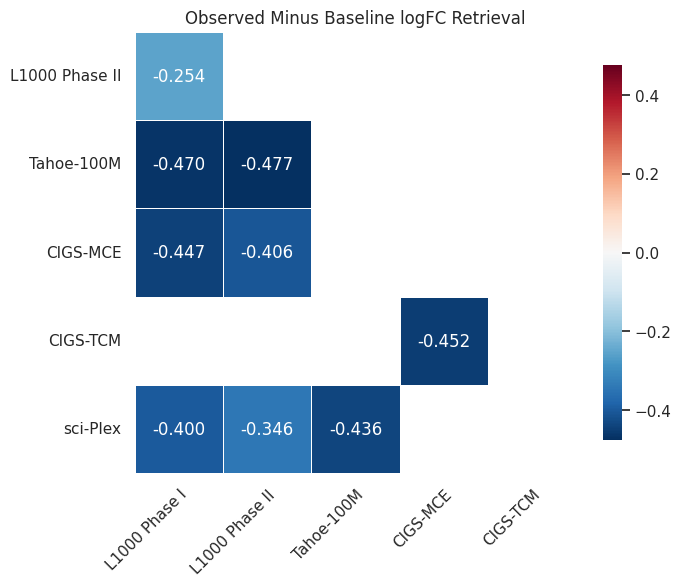

Saved heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_group_rep_retrieval_metrics/dataset_pair_strict_matched_condition_logfc_delta_normalized_rank_heatmap.pdf


In [15]:
plot_pair_metric_heatmap(
    strict_logfc_pair_summary,
    value_col="mean_delta_vs_baseline_normalized_best_positive_rank",
    title="Observed Minus Baseline logFC Retrieval",
    cmap="RdBu_r",
    output_path=RETRIEVAL_HEATMAP_OUTPUT_PATHS["delta"],
    dataset_order=heatmap_dataset_order,
    vmin=None if delta_abs_max is None else -delta_abs_max,
    vmax=None if delta_abs_max is None else delta_abs_max,
    center=0.0,
    cbar_label="Observed - baseline normalized rank",
)
